# Поведенческий скоринг клиентов банка «Ва-банк»: прогноз просрочки 90+ дней

**Заказчик:** розничный банк «Ва-банк», сегмент потребительского кредитования.

**Проблема.** Классический кредитный скоринг оценивает заёмщика один раз - в момент выдачи кредита.
Он не видит клиентов, которые уже получили деньги и начали портиться. Просрочка свыше 90 дней
заставляет банк формировать резервы под 100% проблемного долга, что замораживает капитал,
снижает ликвидность и создаёт регуляторные риски.

**Цель проекта.** Построить модель поведенческого скоринга, которая для клиента в конкретный месяц
предсказывает, возникнет ли у него просрочка длительностью от 90 дней в ближайшие 12 месяцев.
Точный прогноз позволяет заранее управлять резервами и увеличить объём средств в обороте на 5-10%.

**Объект наблюдения:** пара «клиент - месяц скоринга» (`ID`, `score_date`).

**Исходные данные - 8 таблиц:**

| Таблица | Файл | Содержание |
|---|---|---|
| Просрочки | `ds_15_loan_payment_credit.csv` | дата начала периода просрочки и её длительность в днях |
| Транзакции | `ds_15_transactions.csv` | помесячные траты клиента по 7 MCC-кодам и прочим категориям |
| Клиенты | `ds_15_client_description.csv` | возраст, семейное положение, иждивенцы, дата регистрации |
| Кредиты | `ds_15_credit_description.csv` | доход и сумма выданного кредита |
| Ипотека | `ds_15_mortgage_presence.csv` | факт и дата оформления ипотеки |
| Кредитный рейтинг | `ds_15_credit_rating.csv` | помесячный рейтинг из внешнего источника |
| Макроэкономика | `ds_15_macro_data.csv` | учётная ставка, безработица, инфляция по месяцам |
| Сетка скоринга | `ds_15_cohort_grid.csv` | пары «клиент - дата скоринга», для которых нужен прогноз |

**Ключевые требования к качеству:** approval rate не менее 65%, default rate не более 2%,
missed defaults rate не более 4%.

## Постановка задачи в терминах машинного обучения

**Тип задачи:** бинарная классификация с сильным дисбалансом классов и временной структурой данных.

**Целевая переменная** `target` для строки (`ID`, `score_date`):

* `1` - первая просрочка клиента длительностью от 90 дней начинается в интервале
  `[score_date, score_date + 12 месяцев)`;
* `0` - в этом горизонте такой просрочки нет.

**Что будем делать:**

1. **Признаки.** Собираем витрину из 8 источников. Жёсткое правило - в строку с датой `score_date`
   попадают только те данные, которые физически доступны банку **до** этой даты. Помесячные
   источники (транзакции, рейтинг, макро) берём со сдвигом не менее чем на 1 месяц назад,
   потому что месячная агрегация за месяц `t` становится известна только после его окончания.
2. **Новые признаки.** Долговая нагрузка, отношение трат к доходу, тренд и волатильность трат,
   динамика кредитного рейтинга, стаж отношений с банком, структура трат по MCC.
3. **Разделение данных.** Три выборки строго по времени: обучающая, калибровочная и тестовая
   (последние 12 месяцев). Внутри обучающей выборки кросс-валидация на 3 фолдах с
   `GroupTimeSeriesSplit()`, где группой выступает месяц скоринга - фолд валидации всегда лежит
   в будущем относительно фолда обучения.
4. **Модели.** Базовые: логистическая регрессия и случайный лес, каждый в двух вариантах -
   без балансировки и с балансировкой классов. Итоговое решение - `RandomForestClassifier`
   с подобранной стратегией балансировки и гиперпараметрами (Optuna, метрика
   missed defaults rate).
5. **Кодирование.** Категориальный признак кодируем `OneHotEncoder` внутри `Pipeline`,
   числовые масштабируем `StandardScaler` (нужно логистической регрессии). Препроцессор обучается
   только на обучающих фолдах - это защита от утечки.
6. **Калибровка.** Изотоническая калибровка вероятностей случайного леса на отдельной
   калибровочной выборке, контроль по коэффициенту Бриера и графику калибровки.
7. **Порог.** Подбираем порог вероятности так, чтобы approval rate был максимальным при
   default rate не выше 2% и missed defaults rate не выше 4%.

**Метрики:**

* технические - ROC-AUC, accuracy, precision, recall, F1;
* бизнесовые - approval rate = `(TN + FN) / N`, default rate = `FN / (TN + FN)`,
  missed defaults rate = `FN / (FN + TP)`.

Здесь «одобрение» = предсказанный класс 0 (клиент считается надёжным).

**Итоговая мысль.** Задача сводится к ранжированию клиентов по вероятности дефолта и к выбору
порога отсечения, который даёт максимальный объём одобрений при заданных ограничениях на риск.

## Загрузка библиотек

Проект использует три библиотеки, которых нет в базовом окружении: `optuna` (подбор
гиперпараметров), `imbalanced-learn` (методы балансировки классов) и `mlxtend` (реализация
`GroupTimeSeriesSplit`). Ячейка ниже доустанавливает только их и печатает версии; повторный запуск
ничего не меняет.

Версии подобраны под окружение платформы (Python 3.9, scikit-learn 0.24):

* `imbalanced-learn==0.8.1` - последняя ветка, совместимая с scikit-learn 0.24;
* `mlxtend==0.23.4` ставится с `--no-deps`, потому что из него нужен только класс
  `GroupTimeSeriesSplit` (чистый Python), а его метаданные потребовали бы обновления
  scikit-learn - трогать основной стек платформы мы не хотим.

In [1]:
import importlib.util
import subprocess
import sys

import sklearn

# версия imbalanced-learn выбирается по версии scikit-learn: ветка 0.8 - последняя, работающая
# с 0.24, но она не переживает scikit-learn 1.3, где убрали if_delegate_has_method
ВЕРСИЯ_SKLEARN = tuple(int(часть) for часть in sklearn.__version__.split('.')[:2])
ПИН_IMBLEARN = 'imbalanced-learn==0.8.1' if ВЕРСИЯ_SKLEARN < (1, 3) else 'imbalanced-learn'

ЗАВИСИМОСТИ = [
    ('optuna', 'optuna', []),
    (ПИН_IMBLEARN, 'imblearn', []),
    ('mlxtend==0.23.4', 'mlxtend', ['--no-deps']),
]

for пакет, модуль, флаги in ЗАВИСИМОСТИ:
    if importlib.util.find_spec(модуль) is None:
        print(f'Устанавливаю {пакет}...')
        subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', *флаги, пакет], check=True)

import numpy, pandas, sklearn, matplotlib, seaborn, optuna, imblearn, mlxtend

версии = pandas.DataFrame(
    [{'библиотека': m.__name__, 'версия': getattr(m, '__version__', 'н/д')}
     for m in (numpy, pandas, sklearn, matplotlib, seaborn, optuna, imblearn, mlxtend)]
).set_index('библиотека')
версии.columns.name = f'Окружение: Python {sys.version.split()[0]}'
display(версии)

Окружение: Python 3.9.25,версия
библиотека,
numpy,1.21.1
pandas,1.2.4
sklearn,0.24.1
matplotlib,3.3.4
seaborn,0.11.1
optuna,3.6.1
imblearn,0.8.1
mlxtend,0.23.4


In [2]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import optuna
from imblearn.over_sampling import SMOTE, RandomOverSampler
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.under_sampling import RandomUnderSampler
from mlxtend.evaluate import GroupTimeSeriesSplit
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import (accuracy_score, brier_score_loss, confusion_matrix,
                             f1_score, precision_score, recall_score, roc_auc_score)
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 200)
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 110

RANDOM_STATE = 42
HORIZON_MONTHS = 12          # горизонт прогноза целевой переменной
HORIZON_DAYS = 365           # тот же горизонт в днях, как он задан в инструкции к проекту
MIN_DEFAULT_DAYS = 90        # длительность просрочки, которая считается дефолтом

## Загрузка данных

Данные лежат в каталоге `/datasets/` на платформе. Если тетрадь запускается локально,
используется каталог `artifacts/` рядом с тетрадью.

In [3]:
DATA_DIR = Path('/datasets') if Path('/datasets').exists() else Path('artifacts')

FILES = {
    'loan':     ('ds_15_loan_payment_credit.csv', ['дата_начала_периода']),
    'trans':    ('ds_15_transactions.csv',        ['date']),
    'client':   ('ds_15_client_description.csv',  ['дата_регистрации']),
    'credit':   ('ds_15_credit_description.csv',  []),
    'mortgage': ('ds_15_mortgage_presence.csv',   ['дата_открытия']),
    'rating':   ('ds_15_credit_rating.csv',       ['date']),
    'macro':    ('ds_15_macro_data.csv',          ['date']),
    'cohort':   ('ds_15_cohort_grid.csv',         ['score_date']),
}

tables = {name: pd.read_csv(DATA_DIR / fname, parse_dates=dates)
          for name, (fname, dates) in FILES.items()}

loan, trans, client = tables['loan'], tables['trans'], tables['client']
credit, mortgage, rating = tables['credit'], tables['mortgage'], tables['rating']
macro, cohort = tables['macro'], tables['cohort']

MCC_COLS = [c for c in trans.columns if c.startswith('MCC_')]
print('Загружено таблиц:', len(tables))

Загружено таблиц: 8


In [4]:
def показать_шапку(df, name, n=3):
    """Первые строки таблицы с подписью в имени колонок - чтобы не печатать заголовок отдельно."""
    head = df.head(n).copy()
    head.columns.name = name
    display(head)


for name, df in tables.items():
    показать_шапку(df, f'{name}: {df.shape[0]} строк x {df.shape[1]} столбцов')

loan: 5500 строк x 3 столбцов,ID,дата_начала_периода,просрочка_дней
0,IDF55109846,2014-12-01,120
1,IDF54995533,2015-06-01,121
2,IDF54964538,2018-03-01,87


trans: 577494 строк x 10 столбцов,ID,date,MCC_5300,MCC_5814,MCC_5812,MCC_5411,MCC_3990,MCC_5722,MCC_4900,MCC_другое
0,IDF55109846,2013-05-01,3267.59,1282.11,1457.96,5711.10,647.43,2374.78,4059.86,3657.35
1,IDF55109846,2013-06-01,3196.58,2443.37,1334.20,5824.65,1067.55,2187.11,4592.26,3322.61
2,IDF55109846,2013-07-01,3550.54,4277.72,1463.75,5209.51,1167.95,2076.54,3605.25,3467.06


client: 13500 строк x 5 столбцов,ID,возраст,семейное_положение,наличие_иждивенцев,дата_регистрации
0,IDF55109846,41,разведённые,1,2013-05-01
1,IDF54900291,45,разведённые,1,2017-12-01
2,IDF54995533,34,разведённые,1,2013-11-01


credit: 13500 строк x 3 столбцов,ID,доход,сумма_кредита
0,IDF55109846,27035,1960785
1,IDF54900291,64502,3375810
2,IDF54995533,90477,401700


mortgage: 6609 строк x 3 столбцов,ID,дата_открытия,наличие_ипотеки
0,IDF54896351,2013-03-01,1
1,IDF54896367,2018-01-01,1
2,IDF54896414,2018-02-01,1


rating: 577494 строк x 3 столбцов,ID,date,кредитный_рейтинг
0,IDF55109846,2013-05-01,692
1,IDF55109846,2013-06-01,688
2,IDF55109846,2013-07-01,666


macro: 84 строк x 4 столбцов,date,учетная_ставка,уровень_безработицы,инфляция
0,2013-01-01,5.5,5.7,0.97
1,2013-02-01,5.5,5.8,0.56
2,2013-03-01,5.5,5.9,0.34


cohort: 577494 строк x 2 столбцов,ID,score_date
0,IDF55109846,2013-05-01
1,IDF55109846,2013-06-01
2,IDF55109846,2013-07-01


## Исследовательский анализ данных

Проверяем каждую таблицу на пропуски, дубликаты, выбросы и аномалии, а также согласованность
источников между собой.

### Общая сводка по таблицам

In [5]:
def сводка(df, name):
    """Компактная строка-паспорт таблицы для сводного отчёта."""
    return pd.Series({
        'строк': len(df),
        'столбцов': df.shape[1],
        'пропусков': int(df.isna().sum().sum()),
        'полных дубликатов': int(df.duplicated().sum()),
        'уникальных ID': df['ID'].nunique() if 'ID' in df.columns else np.nan,
        'память, МБ': round(df.memory_usage(deep=True).sum() / 1024 ** 2, 1),
    }, name=name)


обзор = pd.DataFrame([сводка(df, name) for name, df in tables.items()])
обзор.columns.name = 'Паспорт таблиц'
display(обзор)

Паспорт таблиц,строк,столбцов,пропусков,полных дубликатов,уникальных ID,"память, МБ"
loan,5500.0,3.0,0.0,0.0,5500.0,0.4
trans,577494.0,10.0,0.0,0.0,13500.0,77.1
client,13500.0,5.0,0.0,0.0,13500.0,2.8
credit,13500.0,3.0,0.0,0.0,13500.0,1.1
mortgage,6609.0,3.0,0.0,0.0,6609.0,0.5
rating,577494.0,3.0,0.0,0.0,13500.0,46.3
macro,84.0,4.0,0.0,0.0,NaN,0.0
cohort,577494.0,2.0,0.0,0.0,13500.0,41.9


In [6]:
покрытие = pd.DataFrame([
    {'таблица': name,
     'уникальных ID': df['ID'].nunique(),
     'нет в client': len(set(df['ID']) - set(client['ID'])),
     'клиентов без записи': client['ID'].nunique() - df['ID'].nunique()}
    for name, df in tables.items() if 'ID' in df.columns
])
покрытие.columns.name = 'Покрытие справочника клиентов'
display(покрытие)

Покрытие справочника клиентов,таблица,уникальных ID,нет в client,клиентов без записи
0,loan,5500,0,8000
1,trans,13500,0,0
2,client,13500,0,0
3,credit,13500,0,0
4,mortgage,6609,0,6891
5,rating,13500,0,0
6,cohort,13500,0,0


### Просрочки платежей

Длительность просрочки: описательные статистики,count,mean,std,min,25%,50%,75%,max
просрочка_дней,5500.0,114.748,20.362422,80.0,97.0,115.0,132.0,150.0


Просрочки,значение
записей о просрочках,5500
уникальных клиентов,5500
эпизодов < 90 дней,788
эпизодов >= 90 дней,4712
клиентов с дефолтом >= 90 дней,4712
доля клиентов банка с дефолтом,0.349
первая дата просрочки,2013-11-01
последняя дата просрочки,2019-12-01


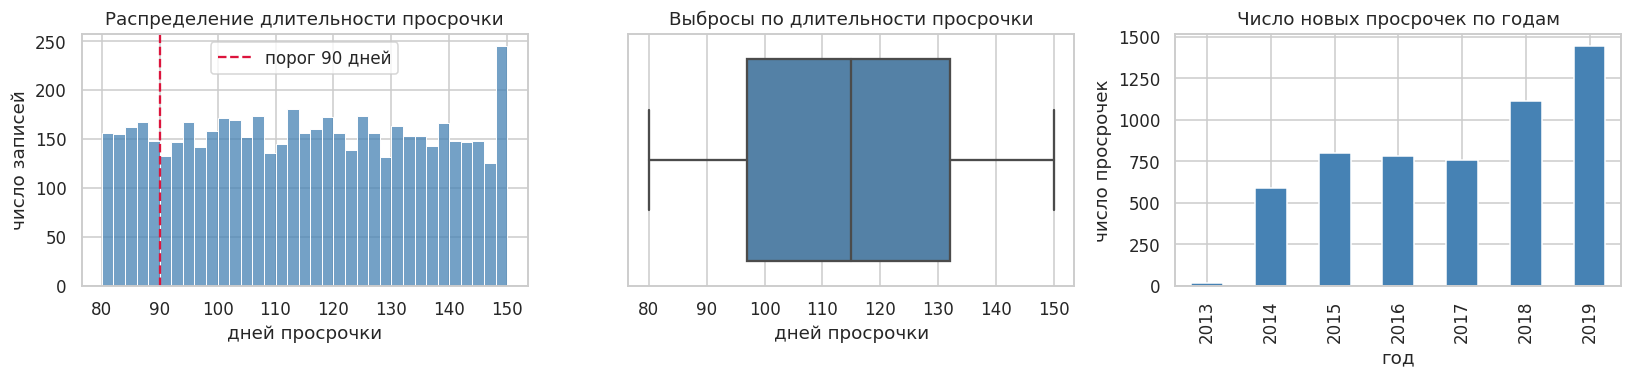

In [7]:
статистики_просрочек = loan['просрочка_дней'].describe().to_frame('просрочка_дней').T
статистики_просрочек.columns.name = 'Длительность просрочки: описательные статистики'
display(статистики_просрочек)

сводка_просрочек = pd.Series({
    'записей о просрочках': len(loan),
    'уникальных клиентов': loan['ID'].nunique(),
    'эпизодов < 90 дней': int((loan['просрочка_дней'] < MIN_DEFAULT_DAYS).sum()),
    'эпизодов >= 90 дней': int((loan['просрочка_дней'] >= MIN_DEFAULT_DAYS).sum()),
    'клиентов с дефолтом >= 90 дней': loan.loc[loan['просрочка_дней'] >= MIN_DEFAULT_DAYS, 'ID'].nunique(),
    'доля клиентов банка с дефолтом': round(
        loan.loc[loan['просрочка_дней'] >= MIN_DEFAULT_DAYS, 'ID'].nunique() / client['ID'].nunique(), 4),
    'первая дата просрочки': loan['дата_начала_периода'].min().date(),
    'последняя дата просрочки': loan['дата_начала_периода'].max().date(),
}).to_frame('значение')
сводка_просрочек.columns.name = 'Просрочки'
display(сводка_просрочек)

fig, axes = plt.subplots(1, 3, figsize=(15, 3.6))
sns.histplot(loan['просрочка_дней'], bins=35, ax=axes[0], color='steelblue')
axes[0].axvline(MIN_DEFAULT_DAYS, color='crimson', ls='--', label='порог 90 дней')
axes[0].set_title('Распределение длительности просрочки')
axes[0].set_xlabel('дней просрочки'); axes[0].set_ylabel('число записей'); axes[0].legend()

sns.boxplot(x=loan['просрочка_дней'], ax=axes[1], color='steelblue')
axes[1].set_title('Выбросы по длительности просрочки')
axes[1].set_xlabel('дней просрочки')

loan.groupby(loan['дата_начала_периода'].dt.to_period('Y').astype(str)).size().plot(
    kind='bar', ax=axes[2], color='steelblue')
axes[2].set_title('Число новых просрочек по годам')
axes[2].set_xlabel('год'); axes[2].set_ylabel('число просрочек')
plt.tight_layout(); plt.show()

### Клиенты и параметры кредитов

Клиенты и кредиты: описательные статистики,count,mean,std,min,25%,50%,75%,max
возраст,13500.0,41.3,15.1,18.0,28.0,40.0,54.0,69.0
доход,13500.0,79089.3,40045.5,15010.0,43347.0,77991.5,113615.5,149988.0
сумма_кредита,13500.0,1993383.5,1061381.4,75000.0,1079328.8,2032732.5,2919236.2,3749400.0


Проверка выбросов по правилу 1.5 IQR,p25,p75,нижний ус,верхний ус,за усами,max
возраст,28.0,54.0,-11.0,93.0,0.0,69.0
доход,43347.0,113615.5,-62055.8,219018.2,0.0,149988.0
сумма_кредита,1079328.8,2919236.2,-1680532.5,5679097.5,0.0,3749400.0


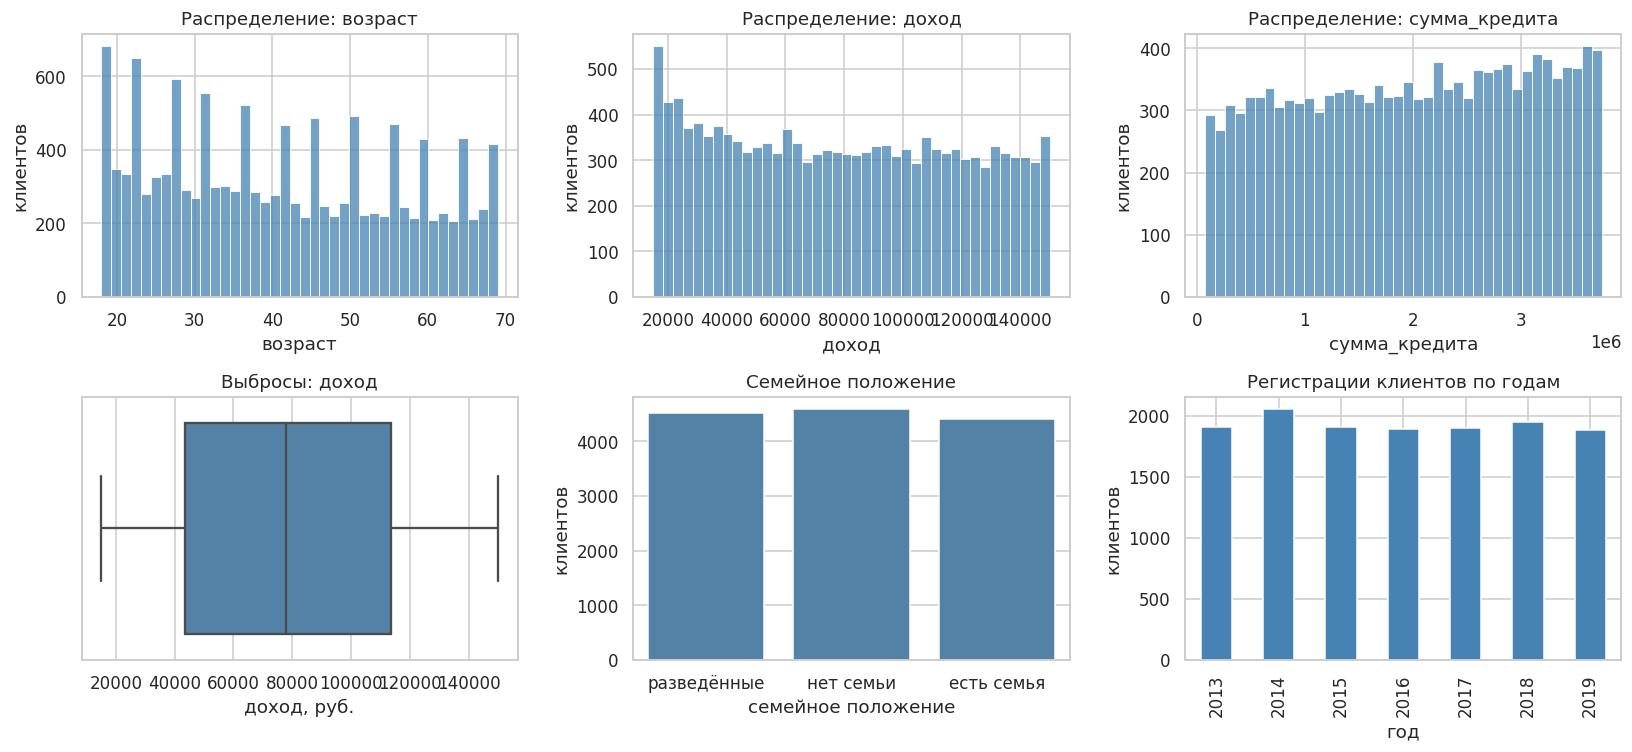

Распределение по семейному положению,доля
нет семьи,0.340
разведённые,0.335
есть семья,0.326


Распределение по наличию иждивенцев,доля
0,0.515
1,0.485


In [8]:
клиенты = client.merge(credit, on='ID', how='left')
статистики_клиентов = клиенты[['возраст', 'доход', 'сумма_кредита']].describe().T
статистики_клиентов.columns.name = 'Клиенты и кредиты: описательные статистики'
display(статистики_клиентов.round(1))


def iqr_отчёт(s):
    """Границы усов и число наблюдений за ними - формальная проверка на выбросы."""
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return pd.Series({'p25': q1, 'p75': q3, 'нижний ус': low, 'верхний ус': high,
                      'за усами': int(((s < low) | (s > high)).sum()), 'max': s.max()}, name=s.name)


iqr_таблица = pd.DataFrame([iqr_отчёт(клиенты[c]) for c in ['возраст', 'доход', 'сумма_кредита']])
iqr_таблица.columns.name = 'Проверка выбросов по правилу 1.5 IQR'
display(iqr_таблица.round(1))

fig, axes = plt.subplots(2, 3, figsize=(15, 7))
for ax, col in zip(axes[0], ['возраст', 'доход', 'сумма_кредита']):
    sns.histplot(клиенты[col], bins=40, ax=ax, color='steelblue')
    ax.set_title(f'Распределение: {col}'); ax.set_xlabel(col); ax.set_ylabel('клиентов')

sns.boxplot(x=клиенты['доход'], ax=axes[1][0], color='steelblue')
axes[1][0].set_title('Выбросы: доход'); axes[1][0].set_xlabel('доход, руб.')
sns.countplot(x='семейное_положение', data=клиенты, ax=axes[1][1], color='steelblue')
axes[1][1].set_title('Семейное положение')
axes[1][1].set_xlabel('семейное положение'); axes[1][1].set_ylabel('клиентов')
client.groupby(client['дата_регистрации'].dt.to_period('Y').astype(str)).size().plot(
    kind='bar', ax=axes[1][2], color='steelblue')
axes[1][2].set_title('Регистрации клиентов по годам')
axes[1][2].set_xlabel('год'); axes[1][2].set_ylabel('клиентов')
plt.tight_layout(); plt.show()

семейное = client['семейное_положение'].value_counts(normalize=True).round(3).to_frame('доля')
семейное.columns.name = 'Распределение по семейному положению'
display(семейное)

иждивенцы = client['наличие_иждивенцев'].value_counts(normalize=True).round(3).to_frame('доля')
иждивенцы.columns.name = 'Распределение по наличию иждивенцев'
display(иждивенцы)

### Ипотека

In [9]:
ипотека_сводка = pd.Series({
    'записей': len(mortgage),
    'уникальных клиентов': mortgage['ID'].nunique(),
    'уникальных значений наличие_ипотеки': mortgage['наличие_ипотеки'].nunique(),
    'значения наличие_ипотеки': ', '.join(map(str, sorted(mortgage['наличие_ипотеки'].unique()))),
    'клиентов без записи об ипотеке': client['ID'].nunique() - mortgage['ID'].nunique(),
    'первая дата открытия': mortgage['дата_открытия'].min().date(),
    'последняя дата открытия': mortgage['дата_открытия'].max().date(),
}).to_frame('значение')
ипотека_сводка.columns.name = 'Ипотека'
display(ипотека_сводка)

Ипотека,значение
записей,6609
уникальных клиентов,6609
уникальных значений наличие_ипотеки,1
значения наличие_ипотеки,1
клиентов без записи об ипотеке,6891
первая дата открытия,2013-01-01
последняя дата открытия,2019-12-01


### Транзакции по MCC-кодам

Месячные траты по MCC-кодам: описательные статистики,count,mean,std,min,25%,50%,75%,max
MCC_5300,577494.0,6177.1,8835.9,162.9,1360.9,2659.6,6561.5,86939.4
MCC_5814,577494.0,3507.7,5710.8,62.2,583.5,1233.1,3642.4,55720.7
MCC_5812,577494.0,2993.9,4541.1,67.1,611.5,1224.5,3201.6,47969.6
MCC_5411,577494.0,9263.1,12299.7,286.1,2139.5,4115.4,9287.5,101302.0
MCC_3990,577494.0,1128.1,1557.2,31.9,245.1,476.9,1159.5,14261.5
MCC_5722,577494.0,3604.4,5005.9,108.4,824.9,1590.1,3866.0,54630.2
MCC_4900,577494.0,3682.5,5568.0,81.3,700.6,1397.1,3872.4,52987.5
MCC_другое,577494.0,5414.9,7190.9,166.3,1250.8,2398.3,5413.5,60033.6


Нулевые траты по категориям,доля нулевых трат
MCC_5300,0.0
MCC_5814,0.0
MCC_5812,0.0
MCC_5411,0.0
MCC_3990,0.0
MCC_5722,0.0
MCC_4900,0.0
MCC_другое,0.0


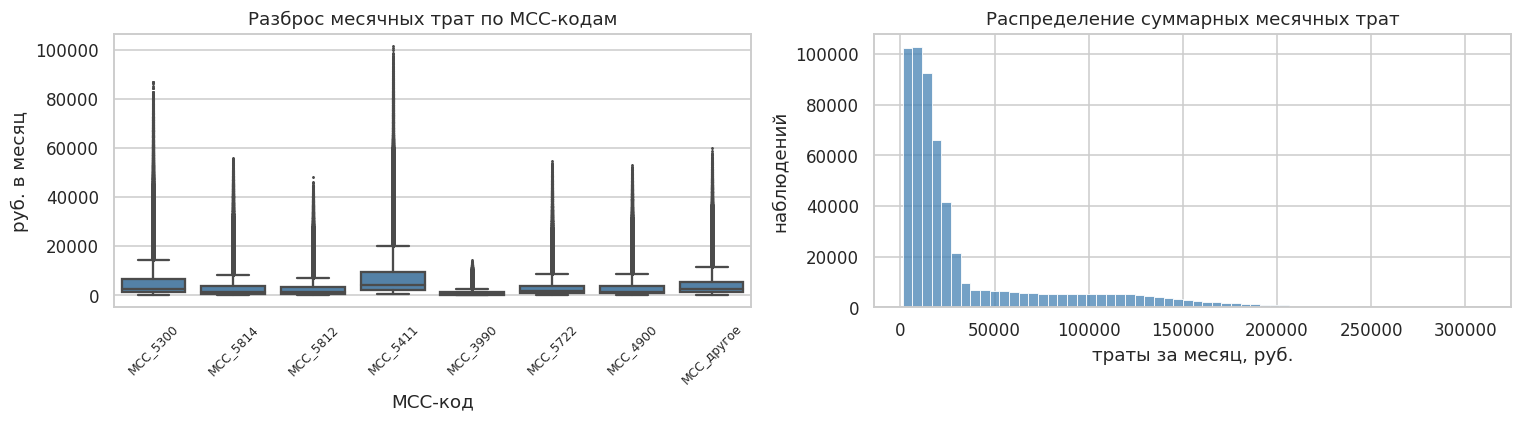

In [10]:
статистики_трат = trans[MCC_COLS].describe().T.round(1)
статистики_трат.columns.name = 'Месячные траты по MCC-кодам: описательные статистики'
display(статистики_трат)

доля_нулей = (trans[MCC_COLS] == 0).mean().round(4).to_frame('доля нулевых трат')
доля_нулей.columns.name = 'Нулевые траты по категориям'
display(доля_нулей)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.boxplot(data=trans[MCC_COLS], ax=axes[0], color='steelblue', fliersize=1)
axes[0].set_title('Разброс месячных трат по MCC-кодам')
axes[0].set_xlabel('MCC-код'); axes[0].set_ylabel('руб. в месяц')
axes[0].tick_params(axis='x', labelrotation=45, labelsize=8)

sns.histplot(trans[MCC_COLS].sum(axis=1), bins=60, ax=axes[1], color='steelblue')
axes[1].set_title('Распределение суммарных месячных трат')
axes[1].set_xlabel('траты за месяц, руб.'); axes[1].set_ylabel('наблюдений')
plt.tight_layout(); plt.show()

### Структура панели наблюдений (cohort_grid)

Проверяем, что сетка скоринга - это регулярная месячная панель: шаг между наблюдениями, длина
истории на клиента, совпадение первого месяца панели с датой регистрации и совпадение самой сетки
с сеткой транзакций.

Структура панели наблюдений,значение
"шаг между наблюдениями, дней",28 - 31 (календарный месяц)
месяцев на клиента: минимум,1
месяцев на клиента: медиана,43
месяцев на клиента: максимум,84
первый месяц панели = дата регистрации,100%
общий период,2013-01-01 - 2019-12-01
совпадение сетки cohort_grid и transactions,True


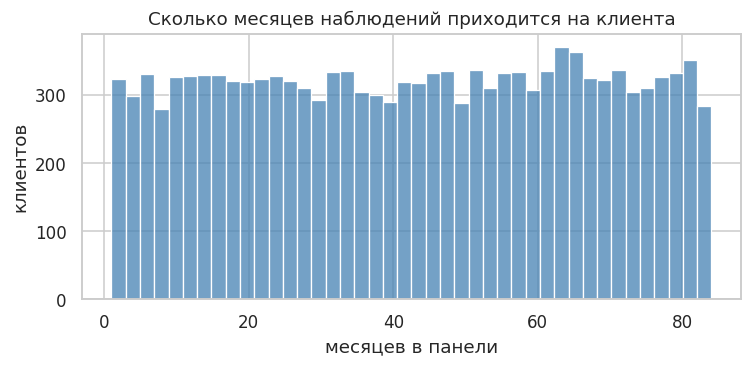

In [11]:
панель = cohort.sort_values(['ID', 'score_date'])
шаг = панель.groupby('ID')['score_date'].diff().dt.days.dropna()
длина_панели = панель.groupby('ID').size()
первый_месяц = панель.groupby('ID')['score_date'].min()
дата_регистрации = client.set_index('ID')['дата_регистрации']

панель_сводка = pd.Series({
    'шаг между наблюдениями, дней': f'{int(шаг.min())} - {int(шаг.max())} (календарный месяц)',
    'месяцев на клиента: минимум': int(длина_панели.min()),
    'месяцев на клиента: медиана': int(длина_панели.median()),
    'месяцев на клиента: максимум': int(длина_панели.max()),
    'первый месяц панели = дата регистрации': f'{(первый_месяц == дата_регистрации.reindex(первый_месяц.index)).mean():.0%}',
    'общий период': f"{cohort['score_date'].min().date()} - {cohort['score_date'].max().date()}",
    'совпадение сетки cohort_grid и transactions': set(map(tuple, cohort[['ID', 'score_date']].values))
                                                   == set(map(tuple, trans[['ID', 'date']].values)),
}).to_frame('значение')
панель_сводка.columns.name = 'Структура панели наблюдений'
display(панель_сводка)

fig, ax = plt.subplots(figsize=(7, 3.5))
sns.histplot(длина_панели, bins=42, ax=ax, color='steelblue')
ax.set_title('Сколько месяцев наблюдений приходится на клиента')
ax.set_xlabel('месяцев в панели'); ax.set_ylabel('клиентов')
plt.tight_layout(); plt.show()

### Кредитный рейтинг

Кредитный рейтинг: описательные статистики,count,mean,std,min,25%,50%,75%,max
кредитный_рейтинг,577494.0,603.2,64.4,343.0,558.0,600.0,646.0,900.0


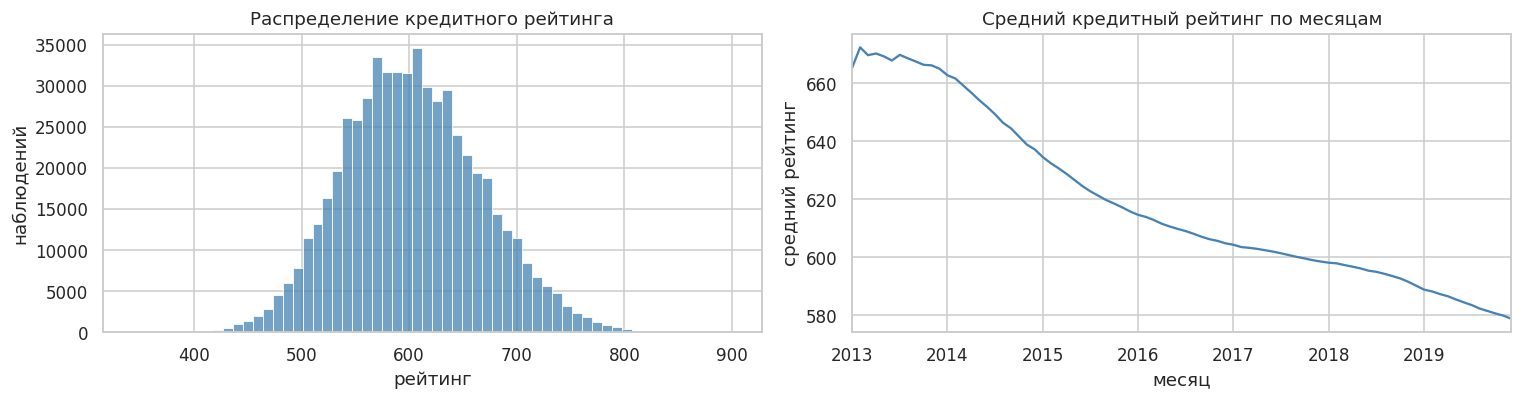

In [12]:
статистики_рейтинга = rating['кредитный_рейтинг'].describe().to_frame('кредитный_рейтинг').T.round(1)
статистики_рейтинга.columns.name = 'Кредитный рейтинг: описательные статистики'
display(статистики_рейтинга)

fig, axes = plt.subplots(1, 2, figsize=(14, 3.8))
sns.histplot(rating['кредитный_рейтинг'], bins=60, ax=axes[0], color='steelblue')
axes[0].set_title('Распределение кредитного рейтинга')
axes[0].set_xlabel('рейтинг'); axes[0].set_ylabel('наблюдений')

rating.groupby('date')['кредитный_рейтинг'].mean().plot(ax=axes[1], color='steelblue')
axes[1].set_title('Средний кредитный рейтинг по месяцам')
axes[1].set_xlabel('месяц'); axes[1].set_ylabel('средний рейтинг')
plt.tight_layout(); plt.show()

### Макроэкономические показатели

Макроэкономические показатели: описательные статистики,count,mean,std,min,25%,50%,75%,max
учетная_ставка,84.0,8.64,2.47,5.50,7.25,7.75,10.33,17.00
уровень_безработицы,84.0,5.18,0.41,4.30,4.90,5.20,5.50,6.00
инфляция,84.0,0.53,0.57,-0.54,0.26,0.42,0.64,3.85


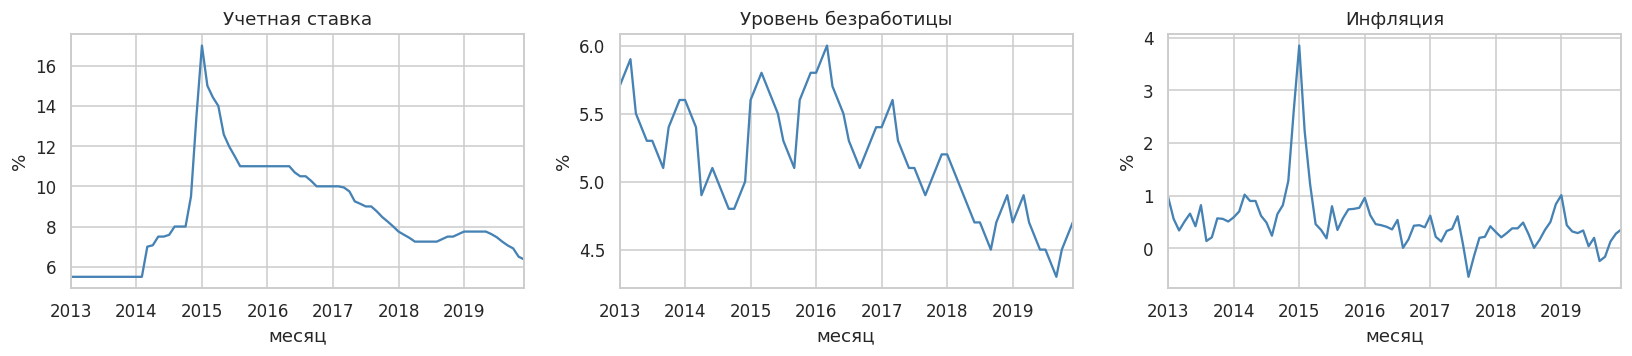

In [13]:
статистики_макро = macro.describe().T.round(2)
статистики_макро.columns.name = 'Макроэкономические показатели: описательные статистики'
display(статистики_макро)

fig, axes = plt.subplots(1, 3, figsize=(15, 3.4))
for ax, col in zip(axes, ['учетная_ставка', 'уровень_безработицы', 'инфляция']):
    macro.set_index('date')[col].plot(ax=ax, color='steelblue')
    ax.set_title(col.replace('_', ' ').capitalize())
    ax.set_xlabel('месяц'); ax.set_ylabel('%')
plt.tight_layout(); plt.show()

### Выводы по исследовательскому анализу данных

**Качество данных.** Во всех восьми таблицах **нет ни одного пропуска и ни одного полного
дубликата**. Идентификаторы согласованы: в каждой таблице встречаются только те `ID`, что есть в
справочнике клиентов.

**Структура наблюдений.** `cohort_grid`, `transactions` и `credit_rating` содержат одинаковую сетку
из 577 494 пар «клиент - месяц» (проверено сравнением множеств): это регулярная месячная панель за
2013-01 - 2019-12 по 13 500 клиентам. Шаг между наблюдениями - календарный месяц (28-31 день),
первый месяц панели совпадает с датой регистрации у 100% клиентов, длина истории от 1 до 84 месяцев
при медиане 43 месяца. Панель начинается с момента прихода клиента в банк, поэтому у «молодых»
клиентов истории мало - это придётся учесть при построении лаговых признаков.

**Просрочки.** 5 500 записей, ровно по одной на клиента - то есть в данных зафиксирован только
один эпизод просрочки на человека. Длительность 80-150 дней (медиана 115). Порогу дефолта не
удовлетворяют 788 эпизодов (< 90 дней), поэтому дефолтом считаем 4 712 клиентов - **34.9% всей
клиентской базы**. Первая просрочка датирована 2013-11, последняя - 2019-12.

**Клиенты и кредиты.** Возраст 18-69 лет (среднее 41.3), доход 15 010 - 149 988 руб. (медиана
77 992), сумма кредита 75 000 - 3 749 400 руб. (медиана 2 032 733). Проверка по правилу 1.5 IQR
даёт **ноль наблюдений за усами** по всем трём признакам: распределения равномерные, выбросов нет.
Категории сбалансированы: семейное положение делится примерно поровну (0.340 / 0.335 / 0.326),
иждивенцы есть у 48.5% клиентов.

**Ипотека.** Таблица содержит только записи со значением 1 (6 609 клиентов). У остальных 6 891
клиента записи нет - это означает не пропуск, а отсутствие ипотеки, поэтому после объединения
безопасно заполняем нулём. Даты открытия покрывают весь период, значит признак нужно строить
на дату скоринга, а не брать факт из будущего.

**Транзакции.** Нулевых трат нет ни в одной категории - клиенты тратят каждый месяц во всех восьми
группах MCC. Распределения сильно скошены вправо: крупнейшая категория - супермаркеты (среднее
9 263 руб. при максимуме 101 302), самая мелкая - экосистема Яндекса (среднее 1 128). Верхние
значения - это не ошибки, а хвост крупных трат, поэтому обрезать их не будем: масштабирование
и деревья справятся сами.

**Кредитный рейтинг.** Диапазон 343-900 при среднем 603, помесячная динамика без разрывов и
аномальных скачков.

**Макроэкономика.** 84 месяца без пропусков: учётная ставка 5.5-17% (пик - кризис конца 2014
года), безработица 4.3-6.0%, месячная инфляция от -0.54% до 3.85%.

**Итоговая мысль.** Данные чистые и полные, предобработка сводится к корректному объединению.
Главный риск проекта - не качество данных, а **утечка из будущего**: все таблицы, кроме
справочников, содержат помесячную историю, и её нужно аккуратно сдвигать относительно даты скоринга.

## Объединение таблиц

### Формирование целевой переменной

Логика полностью повторяет инструкцию к проекту:

1. Для каждого клиента находим **первый по времени** эпизод просрочки длительностью от 90 дней -
   дату начала этого эпизода считаем датой дефолта. Так задано в инструкции: событие датируется
   полем `дата_начала_периода` строки, у которой `просрочка_дней >= 90`, а не моментом, когда
   счётчик просрочки дойдёт до 90 дней.
2. `target = 1`, если дата дефолта попадает в интервал `[score_date, score_date + 365 дней)`.
3. Удаляем строки, где дефолт уже случился к моменту скоринга (`дата_дефолта < score_date`):
   инструкция требует этого явно, и по смыслу поведенческий скоринг для уже дефолтного клиента
   не нужен - его судьбой занимается не скоринг, а взыскание.
4. Дополнительно удаляем строки, у которых **горизонт наблюдения неполный**. Последняя просрочка
   в данных зафиксирована на `2019-12-01`, поэтому для дат скоринга после `2019-01-01` мы физически
   не можем увидеть весь 12-месячный горизонт: часть будущих дефолтов ещё не произошла в данных,
   и такие строки получили бы ложный `target = 0`.

**Важное следствие для оценки качества.** Горизонт таргета длиной год означает, что метка строки
месяца `t` зависит от событий месяцев `t...t+12`. При стыке выборок встык (как требует
постановка задачи: калибровка и тест - по 12 месяцев) горизонты пограничных строк обучающей
выборки заходят на территорию калибровочной. Мы фиксируем это как известное ограничение оценки и
возвращаемся к нему в выводах.

In [14]:
дефолты = (loan.loc[loan['просрочка_дней'] >= MIN_DEFAULT_DAYS]
           .groupby('ID', as_index=False)['дата_начала_периода'].min()
           .rename(columns={'дата_начала_периода': 'дата_дефолта'}))

df = cohort.merge(дефолты, on='ID', how='left')
горизонт = df['score_date'] + pd.Timedelta(days=HORIZON_DAYS)
df['target'] = ((df['дата_дефолта'] >= df['score_date']) & (df['дата_дефолта'] < горизонт)).astype(int)

шаги = [('исходная сетка cohort_grid', len(df), df['target'].mean())]

df = df.loc[~(df['дата_дефолта'] < df['score_date'])].copy()
шаги.append(('после удаления уже случившихся дефолтов', len(df), df['target'].mean()))

последняя_дата_дефолта = loan['дата_начала_периода'].max()
последний_полный_месяц = последняя_дата_дефолта - pd.DateOffset(months=HORIZON_MONTHS - 1)
df = df.loc[df['score_date'] <= последний_полный_месяц].copy()
шаги.append(('после удаления неполного горизонта', len(df), df['target'].mean()))

отчёт = pd.DataFrame(шаги, columns=['шаг', 'строк', 'доля target=1'])
отчёт['доля target=1'] = отчёт['доля target=1'].round(4)
отчёт.columns.name = f'Фильтрация наблюдений (последний полный месяц: {последний_полный_месяц.date()})'
display(отчёт)

Фильтрация наблюдений (последний полный месяц: 2019-01-01),шаг,строк,доля target=1
0,исходная сетка cohort_grid,577494,0.0855
1,после удаления уже случившихся дефолтов,438379,0.1126
2,после удаления неполного горизонта,342993,0.1312


In [15]:
пример_id = дефолты.loc[дефолты['дата_дефолта'].between('2016-01-01', '2016-06-01'), 'ID'].iloc[0]
дата_примера = дефолты.loc[дефолты['ID'] == пример_id, 'дата_дефолта'].iloc[0]
пример = (cohort.loc[cohort['ID'] == пример_id]
          .merge(дефолты, on='ID', how='left')
          .assign(target=lambda d: ((d['дата_дефолта'] >= d['score_date']) &
                                    (d['дата_дефолта'] < d['score_date'] + pd.Timedelta(days=HORIZON_DAYS))
                                    ).astype(int),
                  строка_удалена=lambda d: np.where(d['дата_дефолта'] < d['score_date'],
                                                    'да, дефолт уже произошёл', 'нет')))
пример = пример.loc[пример['score_date'].between(дата_примера - pd.DateOffset(months=14),
                                                 дата_примера + pd.DateOffset(months=2))]
пример.columns.name = (f'Проверка целевой переменной: клиент {пример_id}, '
                       f'дата дефолта {дата_примера.date()}')
display(пример)

"Проверка целевой переменной: клиент IDF54899429, дата дефолта 2016-03-01",ID,score_date,дата_дефолта,target,строка_удалена
6,IDF54899429,2015-01-01,2016-03-01,0,нет
7,IDF54899429,2015-02-01,2016-03-01,0,нет
8,IDF54899429,2015-03-01,2016-03-01,0,нет
9,IDF54899429,2015-04-01,2016-03-01,1,нет
10,IDF54899429,2015-05-01,2016-03-01,1,нет
11,IDF54899429,2015-06-01,2016-03-01,1,нет
12,IDF54899429,2015-07-01,2016-03-01,1,нет
13,IDF54899429,2015-08-01,2016-03-01,1,нет
14,IDF54899429,2015-09-01,2016-03-01,1,нет
15,IDF54899429,2015-10-01,2016-03-01,1,нет


### Сборка признаков без утечки из будущего

Все помесячные источники сдвигаем минимум на один месяц назад: значение за месяц `t` описывает
завершившийся месяц и становится известно банку только после его окончания, поэтому для скоринга
на `score_date` доступны данные месяца `score_date - 1` и раньше.

* **Транзакции:** траты предыдущего месяца, средние траты за 3 предыдущих месяца, разброс трат за
  6 предыдущих месяцев, структура трат по MCC-кодам.
* **Кредитный рейтинг:** значение за предыдущий месяц, минимум за 6 предыдущих месяцев, изменение
  за квартал. Если истории меньше квартала, точкой отсчёта служит первый известный рейтинг клиента.
* **Макроэкономика:** показатели предыдущего месяца плюс изменение ставки за год.
* **Ипотека:** флаг «ипотека уже оформлена на дату скоринга», а не факт из будущего.

In [16]:
trans_s = trans.sort_values(['ID', 'date']).reset_index(drop=True)
trans_s['траты_всего'] = trans_s[MCC_COLS].sum(axis=1)
gt = trans_s.groupby('ID')

признаки_трат = trans_s[['ID', 'date']].copy()
признаки_трат['траты_всего_1м'] = gt['траты_всего'].shift(1)
признаки_трат['траты_средние_3м'] = gt['траты_всего'].transform(
    lambda s: s.shift(1).rolling(3, min_periods=1).mean())
признаки_трат['траты_разброс_6м'] = gt['траты_всего'].transform(
    lambda s: s.shift(1).rolling(6, min_periods=2).std())
for col in MCC_COLS:
    признаки_трат[f'доля_{col}'] = gt[col].shift(1) / признаки_трат['траты_всего_1м']

rating_s = rating.sort_values(['ID', 'date']).reset_index(drop=True)
gr = rating_s.groupby('ID')['кредитный_рейтинг']
признаки_рейтинга = rating_s[['ID', 'date']].copy()
признаки_рейтинга['рейтинг_1м'] = gr.shift(1)
признаки_рейтинга['рейтинг_минимум_6м'] = gr.transform(
    lambda s: s.shift(1).rolling(6, min_periods=1).min())
# сдвиг на 4 месяца = рейтинг за квартал до последнего доступного месяца;
# если истории меньше, точкой отсчёта берём первый известный рейтинг клиента
рейтинг_квартал_назад = gr.shift(4).fillna(gr.transform('first'))
признаки_рейтинга['рейтинг_изменение_3м'] = признаки_рейтинга['рейтинг_1м'] - рейтинг_квартал_назад

macro_s = macro.sort_values('date').reset_index(drop=True)
macro_s['ставка_изменение_12м'] = (macro_s['учетная_ставка']
                                   - macro_s['учетная_ставка'].shift(12).fillna(macro_s['учетная_ставка'].iloc[0]))
macro_s['score_date'] = macro_s['date'] + pd.DateOffset(months=1)
признаки_макро = macro_s.drop(columns=['date'])

df = (df
      .merge(признаки_трат, left_on=['ID', 'score_date'], right_on=['ID', 'date'], how='left').drop(columns='date')
      .merge(признаки_рейтинга, left_on=['ID', 'score_date'], right_on=['ID', 'date'], how='left').drop(columns='date')
      .merge(признаки_макро, on='score_date', how='left')
      .merge(client, on='ID', how='left')
      .merge(credit, on='ID', how='left')
      .merge(mortgage, on='ID', how='left'))

строк_до = len(df)
df = df.loc[df['траты_всего_1м'].notna() & df['рейтинг_1м'].notna()].copy()
print(f'Удалено строк без истории (первый месяц клиента): {строк_до - len(df)}; осталось: {len(df)}')

Удалено строк без истории (первый месяц клиента): 11765; осталось: 331228


Проверяем сборку признаков на том же клиенте: рядом кладём собранный признак и сырое значение
источника за **предыдущий** месяц. Если сдвиг сделан правильно, столбцы совпадут.

In [17]:
проверка = df.loc[df['ID'] == пример_id, ['score_date', 'траты_всего_1м', 'рейтинг_1м', 'учетная_ставка']].copy()
проверка['месяц_источника'] = проверка['score_date'] - pd.DateOffset(months=1)

сырые_траты = trans.assign(траты_сырые=trans[MCC_COLS].sum(axis=1))[['ID', 'date', 'траты_сырые']]
проверка = (проверка
            .merge(сырые_траты.loc[сырые_траты['ID'] == пример_id].drop(columns='ID'),
                   left_on='месяц_источника', right_on='date', how='left').drop(columns='date')
            .merge(rating.loc[rating['ID'] == пример_id, ['date', 'кредитный_рейтинг']]
                   .rename(columns={'кредитный_рейтинг': 'рейтинг_сырой'}),
                   left_on='месяц_источника', right_on='date', how='left').drop(columns='date')
            .merge(macro[['date', 'учетная_ставка']].rename(columns={'учетная_ставка': 'ставка_сырая'}),
                   left_on='месяц_источника', right_on='date', how='left').drop(columns='date'))

assert np.allclose(проверка['траты_всего_1м'], проверка['траты_сырые']), 'Сдвиг трат нарушен'
assert (проверка['рейтинг_1м'] == проверка['рейтинг_сырой']).all(), 'Сдвиг рейтинга нарушен'
assert np.allclose(проверка['учетная_ставка'], проверка['ставка_сырая']), 'Сдвиг макро нарушен'

образец = проверка.head(6)
образец.columns.name = f'Проверка лагов на клиенте {пример_id}: признак против сырого источника'
display(образец)
print('Проверка: все помесячные признаки взяты за месяц до даты скоринга - пройдена')

Проверка лагов на клиенте IDF54899429: признак против сырого источника,score_date,траты_всего_1м,рейтинг_1м,учетная_ставка,месяц_источника,траты_сырые,рейтинг_сырой,ставка_сырая
0,2014-08-01,26400.25,710.0,7.586957,2014-07-01,26400.25,710,7.586957
1,2014-09-01,29323.15,712.0,8.000000,2014-08-01,29323.15,712,8.000000
2,2014-10-01,29538.73,702.0,8.000000,2014-09-01,29538.73,702,8.000000
3,2014-11-01,28544.75,687.0,8.000000,2014-10-01,28544.75,687,8.000000
4,2014-12-01,29596.76,690.0,9.500000,2014-11-01,29596.76,690,9.500000
5,2015-01-01,32948.19,687.0,13.500000,2014-12-01,32948.19,687,13.500000


Проверка: все помесячные признаки взяты за месяц до даты скоринга - пройдена


### Выводы по объединению таблиц

**Фильтрация.** Из исходных 577 494 строк сетки скоринга осталось 331 228:

1. **-139 115 строк (24.1%)** - наблюдения после уже случившегося дефолта. Их удаление требует
   инструкция; по смыслу такие клиенты выбывают из поведенческого скоринга и переходят к взысканию.
2. **-95 386 строк** - месяцы скоринга после 2019-01-01, у которых 12-месячный горизонт выходит за
   границу наблюдаемых данных (последняя просрочка в данных - 2019-12-01). Без этой обрезки такие
   строки получили бы ложный `target = 0` и занизили бы долю дефолтов.
3. **-11 765 строк** - первый месяц каждого клиента, для которого нет ни одного месяца истории,
   поэтому лаговые признаки не определены.

Доля целевого класса при этом закономерно росла: 8.55% → 11.26% → 13.12%.

**Проверка на конкретном клиенте.** Для клиента `IDF54899429` с датой дефолта 2016-03-01 таргет
равен 1 ровно в двенадцати месяцах с 2015-04 по 2016-03, до этого - 0, а строки после даты дефолта
удалены. Это в точности та логика скользящего окна, которая описана в постановке задачи.

**Итоговая мысль.** Витрина собрана по правилу «в строку с датой `score_date` попадает только
прошлое»: помесячные источники сдвинуты минимум на месяц назад, признак ипотеки построен на дату
скоринга, макроэкономика взята за предыдущий месяц. Утечки из будущего в признаках нет.

## Создание новых признаков

Добавляем признаки, которые описывают поведение клиента, а не только его статику на момент выдачи
кредита:

1. `долговая_нагрузка` - сумма кредита к месячному доходу;
2. `траты_к_доходу` - траты прошлого месяца к доходу;
3. `тренд_трат` - траты прошлого месяца к среднему за 3 предыдущих месяца;
4. `волатильность_трат` - разброс трат за полгода к их среднему уровню;
5. `рейтинг_изменение_3м` - динамика кредитного рейтинга за квартал;
6. `рейтинг_минимум_6м` - худшее значение рейтинга за полгода;
7. `доля_обязательных_трат` - доля продуктов и ЖКХ в тратах;
8. `стаж_в_банке_мес` и `возраст_на_дату_скоринга` - положение клиента на временной оси;
9. `ипотека_стаж_мес` - сколько месяцев назад оформлена ипотека.

Чтобы не дублировать информацию, из витрины убираем компоненты, из которых собраны отношения:
`сумма_кредита` (остаются `доход` и `долговая_нагрузка`), абсолютные траты (остаются доли и
`траты_к_доходу`) и одну из долей MCC, поскольку доли в сумме дают единицу.

In [18]:
df['наличие_ипотеки'] = ((df['наличие_ипотеки'] == 1) & (df['дата_открытия'] <= df['score_date'])).astype(int)
df['ипотека_стаж_мес'] = np.where(df['наличие_ипотеки'] == 1,
                                  ((df['score_date'] - df['дата_открытия']).dt.days / 30.44).round(), 0.0)
df['стаж_в_банке_мес'] = ((df['score_date'] - df['дата_регистрации']).dt.days / 30.44).round()
df['возраст_на_дату_скоринга'] = df['возраст'] + df['стаж_в_банке_мес'] / 12
df['долговая_нагрузка'] = df['сумма_кредита'] / df['доход']
df['траты_к_доходу'] = df['траты_всего_1м'] / df['доход']
df['тренд_трат'] = df['траты_всего_1м'] / df['траты_средние_3м']
df['волатильность_трат'] = (df['траты_разброс_6м'] / df['траты_средние_3м']).fillna(0.0)
df['доля_обязательных_трат'] = df['доля_MCC_5411'] + df['доля_MCC_4900']

df = df.drop(columns=['дата_дефолта', 'дата_регистрации', 'дата_открытия', 'сумма_кредита',
                      'возраст', 'траты_всего_1м', 'траты_средние_3м', 'траты_разброс_6м',
                      'доля_MCC_другое'])

НОВЫЕ_ПРИЗНАКИ = ['долговая_нагрузка', 'траты_к_доходу', 'тренд_трат', 'волатильность_трат',
                  'рейтинг_изменение_3м', 'рейтинг_минимум_6м', 'доля_обязательных_трат',
                  'стаж_в_банке_мес', 'возраст_на_дату_скоринга', 'ипотека_стаж_мес']

сравнение = (df.groupby('target')[НОВЫЕ_ПРИЗНАКИ].mean().T
             .rename(columns={0: 'без дефолта', 1: 'дефолт в горизонте 12 мес'}))
сравнение['разница, %'] = ((сравнение['дефолт в горизонте 12 мес'] / сравнение['без дефолта'] - 1) * 100).round(1)
сравнение.columns.name = 'Средние значения новых признаков по классам'
display(сравнение.round(3))

Средние значения новых признаков по классам,без дефолта,дефолт в горизонте 12 мес,"разница, %"
долговая_нагрузка,33.096,49.350,49.1
траты_к_доходу,0.537,1.217,126.8
тренд_трат,0.979,1.055,7.8
волатильность_трат,0.456,0.112,-75.5
рейтинг_изменение_3м,-6.218,-7.583,22.0
рейтинг_минимум_6м,603.391,651.776,8.0
доля_обязательных_трат,0.361,0.359,-0.5
стаж_в_банке_мес,23.907,8.971,-62.5
возраст_на_дату_скоринга,45.820,37.188,-18.8
ипотека_стаж_мес,11.894,4.175,-64.9


### Выводы по новым признакам

Сравнение средних по классам показывает, что новые признаки действительно разделяют клиентов:

* **`траты_к_доходу` - главный сигнал**: у будущих дефолтников 1.217 против 0.537, разница
  **+127%**. Клиент, который тратит больше своего месячного дохода, уходит в просрочку кратно чаще.
* **`стаж_в_банке_мес` - 9.0 месяца против 23.9 (-62%)**: дефолты концентрируются в первые месяцы
  после выдачи кредита. То же самое видно по `ипотека_стаж_мес` (-65%).
* **`долговая_нагрузка` - 49.4 против 33.1 (+49%)**: чем больше кредит относительно дохода,
  тем выше риск.
* **`волатильность_трат` - 0.112 против 0.456 (-76%)**: у будущих дефолтников траты, наоборот,
  стабильно высокие, без провалов. Это не «рваное» потребление, а устойчивая жизнь не по средствам.
* **`возраст_на_дату_скоринга` - 37.2 против 45.8 лет**: молодые заёмщики рискованнее.
* **`рейтинг_минимум_6м` ведёт себя контринтуитивно**: у будущих дефолтников он **выше**
  (651.8 против 603.4), хотя по смыслу рейтинга должно быть наоборот. Связь с целевой переменной
  есть и она сильная, но её знак обратный ожидаемому. Это не «слабый признак», а сигнал о
  проблеме в самом источнике: либо шкала внешнего рейтинга инвертирована, либо рейтинг обновляется
  уже после того, как банк реагирует на риск. Разбираться с этим нужно с поставщиком данных.

**Защита от мультиколлинеарности.** Из витрины удалены компоненты, из которых собраны отношения:
`сумма_кредита` (осталась `долговая_нагрузка` и `доход`), абсолютные суммы трат (остались доли и
`траты_к_доходу`) и одна из долей MCC, поскольку восемь долей в сумме дают единицу.

**Итоговая мысль.** Поведенческие признаки - соотношение трат и дохода, долговая нагрузка и стаж
отношений с банком - разделяют классы заметно сильнее, чем статические анкетные данные.

## Анализ итоговой таблицы

In [19]:
структура = pd.DataFrame({'тип': df.dtypes.astype(str),
                          'пропусков': df.isna().sum(),
                          'уникальных': df.nunique()})
структура.columns.name = f'Витрина: {df.shape[0]} строк x {df.shape[1]} столбцов'
display(структура)

assert df.isna().sum().sum() == 0, 'В витрине остались пропуски'

статистики_витрины = df.describe().T.round(3)
статистики_витрины.columns.name = 'Итоговая витрина: описательные статистики'
display(статистики_витрины)

Витрина: 331228 строк x 29 столбцов,тип,пропусков,уникальных
ID,object,0,11613
score_date,datetime64[ns],0,72
target,int64,0,2
доля_MCC_5300,float64,0,331226
доля_MCC_5814,float64,0,331227
доля_MCC_5812,float64,0,331225
доля_MCC_5411,float64,0,331227
доля_MCC_3990,float64,0,331223
доля_MCC_5722,float64,0,331225
доля_MCC_4900,float64,0,331226


Итоговая витрина: описательные статистики,count,mean,std,min,25%,50%,75%,max
target,331228.0,0.132,0.338,0.000,0.000,0.000,0.000,1.000
доля_MCC_5300,331228.0,0.173,0.057,0.103,0.133,0.146,0.193,0.335
доля_MCC_5814,331228.0,0.097,0.058,0.034,0.049,0.057,0.163,0.233
доля_MCC_5812,331228.0,0.083,0.035,0.043,0.057,0.062,0.098,0.173
доля_MCC_5411,331228.0,0.259,0.032,0.185,0.235,0.251,0.275,0.376
доля_MCC_3990,331228.0,0.031,0.008,0.018,0.025,0.028,0.041,0.057
доля_MCC_5722,331228.0,0.104,0.039,0.063,0.083,0.089,0.100,0.249
доля_MCC_4900,331228.0,0.102,0.050,0.048,0.065,0.073,0.157,0.220
рейтинг_1м,331228.0,618.087,67.220,367.000,570.000,618.000,665.000,900.000
рейтинг_минимум_6м,331228.0,609.754,68.030,367.000,561.000,609.000,657.000,900.000


"Баланс классов, дисбаланс 1:6.6",строк,доля
нет дефолта (0),287669,0.8685
дефолт в горизонте 12 мес (1),43559,0.1315


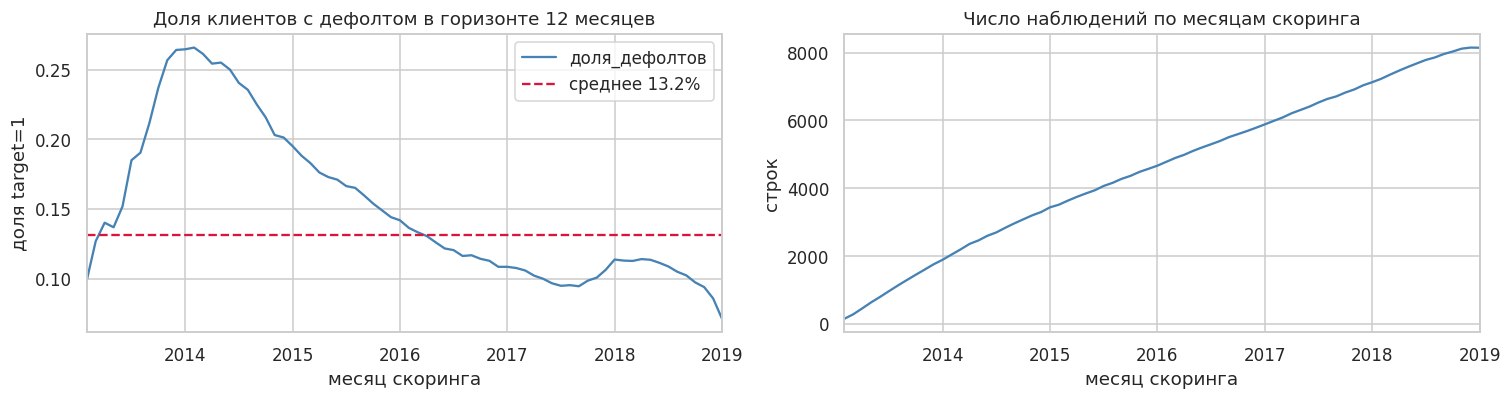

In [20]:
баланс = df['target'].value_counts().to_frame('строк')
баланс['доля'] = (баланс['строк'] / len(df)).round(4)
баланс.index = ['нет дефолта (0)', 'дефолт в горизонте 12 мес (1)']
баланс.columns.name = f'Баланс классов, дисбаланс 1:{round(баланс.loc["нет дефолта (0)", "строк"] / баланс.loc["дефолт в горизонте 12 мес (1)", "строк"], 1)}'
display(баланс)

помесячно = df.groupby('score_date').agg(строк=('target', 'size'), доля_дефолтов=('target', 'mean'))

fig, axes = plt.subplots(1, 2, figsize=(14, 3.8))
помесячно['доля_дефолтов'].plot(ax=axes[0], color='steelblue')
axes[0].axhline(df['target'].mean(), color='crimson', ls='--', label=f"среднее {df['target'].mean():.1%}")
axes[0].set_title('Доля клиентов с дефолтом в горизонте 12 месяцев')
axes[0].set_xlabel('месяц скоринга'); axes[0].set_ylabel('доля target=1'); axes[0].legend()

помесячно['строк'].plot(ax=axes[1], color='steelblue')
axes[1].set_title('Число наблюдений по месяцам скоринга')
axes[1].set_xlabel('месяц скоринга'); axes[1].set_ylabel('строк')
plt.tight_layout(); plt.show()

### Выводы по итоговой таблице

**Размер и качество.** Витрина - 331 228 строк и 29 столбцов: 26 признаков, идентификатор клиента,
дата скоринга и таргет. Пропусков нет (проверено `assert`), типы корректные, в выборке 11 613
уникальных клиентов и 72 месяца скоринга (2013-02 - 2019-01).

**Баланс классов.** Дефолт в горизонте 12 месяцев ожидается у **13.15%** наблюдений
(43 559 строк против 287 669), дисбаланс **1:6.6**. Выводы отсюда два:

1. **accuracy как основная метрика непригодна** - модель, предсказывающая «дефолта не будет»
   всем подряд, получит 86.9% точности и нулевую пользу. Поэтому основными считаем ROC-AUC и
   бизнес-метрики.
2. **балансировка классов обязательна** - иначе модель почти не будет предсказывать редкий класс.
   Сравним `class_weight`, `RandomOverSampler`, `RandomUnderSampler` и `SMOTE`.

**Динамика во времени.** График доли дефолтов по месяцам показывает не плавный тренд, а горб:
уровень риска быстро растёт в 2013 году, достигает максимума в начале 2014 года и затем устойчиво
снижается до конца периода. Разрыв огромный - в обучающем периоде средняя доля дефолтов 16.4%,
а в калибровочном и тестовом уже 10.1% и 10.2% (см. таблицу разделения выборок ниже).
Портфель взрослеет, а вместе с ним меняется уровень риска, поэтому случайное перемешивание
данных недопустимо: выборки нарезаем строго по времени, иначе модель будет учиться на «будущем»
уровне дефолтности.

**Итоговая мысль.** Данные готовы к моделированию: пропусков нет, признаки поведенческие,
дисбаланс умеренный и лечится балансировкой, а временная структура требует хронологического
разделения выборок.

## Моделирование

### Формирование выборок

Данные разделяем строго по времени, без перемешивания:

* **тестовая выборка** - последние 12 месяцев скоринга;
* **калибровочная выборка** - предыдущие 12 месяцев;
* **обучающая выборка** - вся более ранняя история.

Такое разделение имитирует реальную эксплуатацию: модель обучается на прошлом и применяется к
будущему. Выборки нарезаем не вручную, а тем же инструментом, который учитывает и группировку, и
время - `GroupTimeSeriesSplit()` с группой «месяц скоринга»: сначала отделяем 12 тестовых месяцев,
затем тем же способом отделяем 12 калибровочных от оставшейся истории. Внутри обучающей выборки
`GroupTimeSeriesSplit()` используется повторно - уже для трёх фолдов кросс-валидации.

In [21]:
df = df.sort_values(['score_date', 'ID']).reset_index(drop=True)
ОКНО = 12


def отделить_последние_месяцы(данные, месяцев):
    """GroupTimeSeriesSplit по группе «месяц скоринга»: прошлое - в первую часть, последние
    `месяцев` месяцев - во вторую. Гарантирует, что вторая часть целиком лежит в будущем."""
    группы = данные['score_date'].rank(method='dense').astype(int).values - 1
    разбиение = GroupTimeSeriesSplit(test_size=месяцев, n_splits=1)
    прошлое, будущее = next(iter(разбиение.split(данные, данные['target'], группы)))
    return данные.iloc[прошлое].reset_index(drop=True), данные.iloc[будущее].reset_index(drop=True)


обучение_и_калибровка, test = отделить_последние_месяцы(df, ОКНО)
train, calib = отделить_последние_месяцы(обучение_и_калибровка, ОКНО)

выборки = pd.DataFrame([
    {'выборка': name, 'месяцев': part['score_date'].nunique(), 'строк': len(part),
     'клиентов': part['ID'].nunique(), 'доля target=1': round(part['target'].mean(), 4),
     'период': f"{part['score_date'].min().date()} - {part['score_date'].max().date()}"}
    for name, part in [('обучающая', train), ('калибровочная', calib), ('тестовая', test)]])
выборки.columns.name = 'Разделение выборок по времени'
display(выборки)

assert train['score_date'].max() < calib['score_date'].min() < test['score_date'].min()
print('Проверка: выборки не пересекаются во времени - пройдена')

Разделение выборок по времени,выборка,месяцев,строк,клиентов,доля target=1,период
0,обучающая,48,159071,7767,0.1638,2013-02-01 - 2017-01-01
1,калибровочная,12,78794,7733,0.1013,2017-02-01 - 2018-01-01
2,тестовая,12,93363,9026,0.1019,2018-02-01 - 2019-01-01


Проверка: выборки не пересекаются во времени - пройдена


**Ограничение, которое нужно измерить.** Метка строки зависит от событий следующих 12 месяцев,
поэтому у пограничных строк обучающей выборки горизонт таргета заходит в календарный период
калибровочной. Один и тот же эпизод просрочки при этом даёт до 12 положительных строк подряд, и
часть дефолтных клиентов встречается по обе стороны границы. Измерим масштаб эффекта - это
понадобится при интерпретации метрик.

In [22]:
def дефолтные_клиенты(часть):
    return set(часть.loc[часть['target'] == 1, 'ID'])


пересечения = pd.DataFrame([
    {'показатель': 'доля строк обучающей выборки, чей 12-месячный горизонт заходит в период калибровочной',
     'значение': (train['score_date'] + pd.Timedelta(days=HORIZON_DAYS) > calib['score_date'].min()).mean()},
    {'показатель': 'доля дефолтных клиентов калибровочной выборки, уже отмеченных дефолтом в обучающей',
     'значение': len(дефолтные_клиенты(calib) & дефолтные_клиенты(train)) / len(дефолтные_клиенты(calib))},
    {'показатель': 'доля дефолтных клиентов тестовой выборки, уже отмеченных дефолтом в калибровочной',
     'значение': len(дефолтные_клиенты(test) & дефолтные_клиенты(calib)) / len(дефолтные_клиенты(test))},
    {'показатель': 'доля дефолтных клиентов тестовой выборки, уже отмеченных дефолтом в обучающей',
     'значение': len(дефолтные_клиенты(test) & дефолтные_клиенты(train)) / len(дефолтные_клиенты(test))},
]).set_index('показатель')
пересечения.columns.name = 'Пересечение горизонтов целевой переменной между выборками'
display(пересечения.round(4))

Пересечение горизонтов целевой переменной между выборками,значение
показатель,
"доля строк обучающей выборки, чей 12-месячный горизонт заходит в период калибровочной",0.3731
"доля дефолтных клиентов калибровочной выборки, уже отмеченных дефолтом в обучающей",0.4163
"доля дефолтных клиентов тестовой выборки, уже отмеченных дефолтом в калибровочной",0.5199
"доля дефолтных клиентов тестовой выборки, уже отмеченных дефолтом в обучающей",0.0000


### Пайплайн предобработки и схема кросс-валидации

Категориальный признак кодируем `OneHotEncoder(handle_unknown='ignore')` - на проде может
встретиться категория, которой не было в обучении. Числовые масштабируем `StandardScaler`. Оба преобразования лежат внутри `Pipeline`, поэтому обучаются только на
обучающей части каждого фолда - утечки статистик из валидации нет.

In [23]:
КАТЕГОРИАЛЬНЫЕ = ['семейное_положение']
ЧИСЛОВЫЕ = [c for c in df.columns if c not in КАТЕГОРИАЛЬНЫЕ + ['ID', 'score_date', 'target']]

X_train, y_train = train[КАТЕГОРИАЛЬНЫЕ + ЧИСЛОВЫЕ], train['target']
X_calib, y_calib = calib[КАТЕГОРИАЛЬНЫЕ + ЧИСЛОВЫЕ], calib['target']
X_test, y_test = test[КАТЕГОРИАЛЬНЫЕ + ЧИСЛОВЫЕ], test['target']

группы_train = train['score_date'].rank(method='dense').astype(int).values - 1


def препроцессор():
    """Новый экземпляр препроцессора: OHE для категорий, стандартизация для числовых."""
    return ColumnTransformer([
        ('cat', OneHotEncoder(handle_unknown='ignore'), КАТЕГОРИАЛЬНЫЕ),
        ('num', StandardScaler(), ЧИСЛОВЫЕ),
    ])


# shift_size=8 сдвигает окно валидации на его полную длину: иначе окна соседних фолдов
# перекрывались бы на 7 месяцев из 8 и три фолда давали бы почти одну и ту же оценку
CV = GroupTimeSeriesSplit(test_size=8, n_splits=3, shift_size=8, window_type='expanding')
ФОЛДЫ = list(CV.split(X_train, y_train, группы_train))

фолды_отчёт = pd.DataFrame([
    {'фолд': i + 1,
     'обучение: месяцы': f'{группы_train[tr].min() + 1}-{группы_train[tr].max() + 1}',
     'обучение: строк': len(tr),
     'валидация: месяцы': f'{группы_train[va].min() + 1}-{группы_train[va].max() + 1}',
     'валидация: строк': len(va),
     'доля target=1 на валидации': round(y_train.iloc[va].mean(), 4)}
    for i, (tr, va) in enumerate(ФОЛДЫ)])
фолды_отчёт.columns.name = f'GroupTimeSeriesSplit: {len(ФОЛДЫ)} фолда, группа = месяц скоринга'
display(фолды_отчёт)

окна = [set(группы_train[va]) for _, va in ФОЛДЫ]
assert all(not (a & b) for i, a in enumerate(окна) for b in окна[i + 1:]), 'Окна валидации пересекаются'
print('Проверка: валидационные окна фолдов не пересекаются - пройдена')

"GroupTimeSeriesSplit: 3 фолда, группа = месяц скоринга",фолд,обучение: месяцы,обучение: строк,валидация: месяцы,валидация: строк,доля target=1 на валидации
0,1,1-24,45632,25-32,31205,0.1722
1,2,1-32,76837,33-40,37868,0.1389
2,3,1-40,114705,41-48,44366,0.1146


Проверка: валидационные окна фолдов не пересекаются - пройдена


### Метрики качества

Одобрение клиента - это предсказанный класс 0. Отсюда бизнес-метрики:

* **approval rate** = `(TN + FN) / N` - доля одобренных клиентов;
* **default rate** = `FN / (TN + FN)` - доля дефолтов внутри одобренных;
* **missed defaults rate** = `FN / (FN + TP)` - доля пропущенных дефолтов, равна `1 - recall`.

In [24]:
def бизнес_метрики(y_true, y_pred):
    """Метрики банка: сколько одобрили, сколько дефолтов внутри одобренных и сколько пропустили."""
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    одобрен = y_pred == 0
    tn = int(((y_true == 0) & одобрен).sum())
    fn = int(((y_true == 1) & одобрен).sum())
    tp = int(((y_true == 1) & ~одобрен).sum())
    return {'approval_rate': одобрен.mean(),
            'default_rate': fn / max(tn + fn, 1),
            'missed_defaults_rate': fn / max(fn + tp, 1)}


def все_метрики(y_true, proba, порог=0.5):
    """Технические и бизнес-метрики для одного порога отсечения."""
    y_pred = (proba >= порог).astype(int)
    результат = {'ROC_AUC': roc_auc_score(y_true, proba),
                 'accuracy': accuracy_score(y_true, y_pred),
                 'precision': precision_score(y_true, y_pred, zero_division=0),
                 'recall': recall_score(y_true, y_pred, zero_division=0),
                 'f1': f1_score(y_true, y_pred, zero_division=0)}
    результат.update(бизнес_метрики(y_true, y_pred))
    return результат


def метрики_при_одобрении(y_true, proba, доля_одобрений):
    """Метрики в точке, где банк одобряет заданную долю клиентов с наименьшим риском."""
    порог = np.quantile(proba, доля_одобрений)
    return бизнес_метрики(y_true, (proba >= порог).astype(int))


УРОВНИ_ОДОБРЕНИЯ = [0.65, 0.70, 0.75, 0.80]
print('Функции метрик готовы')

Функции метрик готовы


### Базовые модели

Сравниваем четыре базовые конфигурации на кросс-валидации по трём фолдам: логистическую регрессию
и случайный лес, каждый - без балансировки и с `class_weight='balanced'`. Порог по умолчанию 0.5.

In [25]:
def оценить_cv(модель, название):
    """Кросс-валидация по временным фолдам: усредняем технические и бизнес-метрики."""
    строки = []
    for tr, va in ФОЛДЫ:
        модель.fit(X_train.iloc[tr], y_train.iloc[tr])
        proba = модель.predict_proba(X_train.iloc[va])[:, 1]
        метрики = все_метрики(y_train.iloc[va], proba)
        метрики['MDR при AR 65-80%'] = np.mean(
            [метрики_при_одобрении(y_train.iloc[va], proba, ar)['missed_defaults_rate']
             for ar in УРОВНИ_ОДОБРЕНИЯ])
        строки.append(метрики)
    результат = pd.DataFrame(строки).mean().to_dict()
    результат['модель'] = название
    return результат


базовые_модели = {
    'Логистическая регрессия': ImbPipeline([
        ('prep', препроцессор()),
        ('clf', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))]),
    'Логистическая регрессия + class_weight': ImbPipeline([
        ('prep', препроцессор()),
        ('clf', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE))]),
    'Случайный лес': ImbPipeline([
        ('prep', препроцессор()),
        ('clf', RandomForestClassifier(n_estimators=100, min_samples_leaf=5,
                                       random_state=RANDOM_STATE, n_jobs=-1))]),
    'Случайный лес + class_weight': ImbPipeline([
        ('prep', препроцессор()),
        ('clf', RandomForestClassifier(n_estimators=100, min_samples_leaf=5, class_weight='balanced',
                                       random_state=RANDOM_STATE, n_jobs=-1))]),
}

базовые_результаты = pd.DataFrame([оценить_cv(m, n) for n, m in базовые_модели.items()])
базовые_результаты = базовые_результаты.set_index('модель')
базовые_результаты.columns.name = 'Базовые модели, среднее по 3 фолдам (порог 0.5)'
display(базовые_результаты.round(4))

"Базовые модели, среднее по 3 фолдам (порог 0.5)",ROC_AUC,accuracy,precision,recall,f1,approval_rate,default_rate,missed_defaults_rate,MDR при AR 65-80%
модель,,,,,,,,,
Логистическая регрессия,0.8599,0.8594,0.5123,0.1805,0.2667,0.9504,0.1226,0.8195,0.2765
Логистическая регрессия + class_weight,0.8598,0.7816,0.3671,0.7598,0.4940,0.7097,0.0498,0.2402,0.2769
Случайный лес,0.8967,0.8710,0.6119,0.2467,0.3512,0.9427,0.1135,0.7533,0.1968
Случайный лес + class_weight,0.8970,0.8573,0.4959,0.5528,0.5223,0.8431,0.0760,0.4472,0.1957


### Выводы по базовым моделям

**Без балансировки модели бесполезны для банка.** При пороге 0.5 логистическая регрессия ловит
лишь 18.1% дефолтов (recall 0.1805), случайный лес - 24.7%. Approval rate 95.0% и 94.3% выглядят
прекрасно, но за ними прячется **missed defaults rate 82.0% и 75.3%**: три-четыре из пяти будущих
неплательщиков получают одобрение. Default rate внутри одобренных - 12.3% и 11.4%, что в шесть
раз выше допустимых 2%.

**Балансировка радикально меняет картину.** С `class_weight='balanced'` логистическая регрессия
поднимает recall до 0.7598 (missed defaults rate 24.0%), случайный лес - до 0.5528 (44.7%). Ценой
становится approval rate: 71.0% и 84.3% соответственно.

**Случайный лес сильнее логистической регрессии** по разделяющей способности: ROC-AUC 0.8967-0.8970
против 0.8598-0.8599 в среднем по трём фолдам. Разрыв объясняется нелинейностью зависимостей:
отношение трат к доходу и стаж работают «пороговыми» эффектами, которые линейная модель не
улавливает.

**Ключевая метрика проекта - missed defaults rate в рабочем диапазоне одобрений 65-80%** - тоже
за случайный лес: 0.1957 (с `class_weight`) и 0.1968 (без) против 0.2765 и 0.2769 у логистической
регрессии. Разница в 1.4 раза: при одинаковом объёме одобрений линейная модель пропускает
существенно больше дефолтов.

**Итоговая мысль.** Дальше работаем со случайным лесом, а порог 0.5 использовать не будем - его
подберём отдельно под бизнес-ограничения.

### Выбор метода балансировки классов

Дисбаланс классов лечим четырьмя способами и сравниваем их на одной и той же модели -
случайном лесе с фиксированными параметрами. Сравниваем по missed defaults rate в рабочем
диапазоне одобрений 65-80%: именно эта метрика показывает, сколько будущих дефолтов модель
пропускает при разумном объёме одобрений.

In [26]:
def лес(**kwargs):
    return RandomForestClassifier(n_estimators=100, min_samples_leaf=5,
                                  random_state=RANDOM_STATE, n_jobs=-1, **kwargs)


варианты_балансировки = {
    'без балансировки': ImbPipeline([('prep', препроцессор()), ('clf', лес())]),
    'class_weight=balanced': ImbPipeline([('prep', препроцессор()), ('clf', лес(class_weight='balanced'))]),
    'RandomOverSampler': ImbPipeline([('prep', препроцессор()),
                                      ('bal', RandomOverSampler(random_state=RANDOM_STATE)), ('clf', лес())]),
    'RandomUnderSampler': ImbPipeline([('prep', препроцессор()),
                                       ('bal', RandomUnderSampler(random_state=RANDOM_STATE)), ('clf', лес())]),
    'SMOTE': ImbPipeline([('prep', препроцессор()),
                          ('bal', SMOTE(random_state=RANDOM_STATE)), ('clf', лес())]),
}

балансировка_результаты = (pd.DataFrame([оценить_cv(m, n) for n, m in варианты_балансировки.items()])
                           .set_index('модель')
                           .sort_values('MDR при AR 65-80%'))
балансировка_результаты.columns.name = 'Методы балансировки, среднее по 3 фолдам'
display(балансировка_результаты.round(4))

ЛУЧШАЯ_БАЛАНСИРОВКА = балансировка_результаты.index[0]
print('Выбранный метод балансировки:', ЛУЧШАЯ_БАЛАНСИРОВКА)

"Методы балансировки, среднее по 3 фолдам",ROC_AUC,accuracy,precision,recall,f1,approval_rate,default_rate,missed_defaults_rate,MDR при AR 65-80%
модель,,,,,,,,,
RandomOverSampler,0.8996,0.8554,0.4909,0.6022,0.5405,0.8272,0.0691,0.3978,0.1912
class_weight=balanced,0.8970,0.8573,0.4959,0.5528,0.5223,0.8431,0.0760,0.4472,0.1957
без балансировки,0.8967,0.8710,0.6119,0.2467,0.3512,0.9427,0.1135,0.7533,0.1968
SMOTE,0.8929,0.8286,0.4367,0.7362,0.5475,0.7631,0.0505,0.2638,0.2015
RandomUnderSampler,0.8909,0.7916,0.3905,0.8545,0.5350,0.6932,0.0319,0.1455,0.2084


Выбранный метод балансировки: RandomOverSampler


### Выводы о методе балансировки

По ключевой метрике - **missed defaults rate в диапазоне одобрений 65-80%** - методы выстроились так:

| Метод | MDR при AR 65-80% | ROC-AUC |
|---|---|---|
| RandomOverSampler | **0.1912** | **0.8996** |
| class_weight='balanced' | 0.1957 | 0.8970 |
| без балансировки | 0.1968 | 0.8967 |
| SMOTE | 0.2015 | 0.8929 |
| RandomUnderSampler | 0.2084 | 0.8909 |

**Выбираем `RandomOverSampler`:** он даёт одновременно лучший missed defaults rate и лучший
ROC-AUC. Разрыв с `class_weight` невелик (0.0045 по MDR), но направление совпадает по обеим
метрикам, поэтому выбор устойчив.

**Почему проиграл `RandomUnderSampler`.** Чтобы выровнять классы, он отбрасывает большую часть
объектов мажорного класса, а вместе с ними - информацию о том, как выглядит надёжный заёмщик.
При пороге 0.5 он показывает самый высокий recall (0.8545), но в рабочем режиме, когда порог
подбирается под approval rate, уступает всем: ранжирование получается хуже (ROC-AUC 0.8909 -
худший результат в таблице).

**Почему SMOTE не помог.** Синтетические объекты строятся интерполяцией между соседями редкого
класса, а у нас признаки в основном поведенческие отношения. Их линейные комбинации порождают
клиентов, которых не бывает, и это слегка размывает границу классов.

**Итоговая мысль.** Простое дублирование объектов редкого класса (`RandomOverSampler`) работает
лучше и синтетики, и весов классов, поэтому дальше настраиваем именно эту связку.

### Подбор гиперпараметров Random Forest с помощью Optuna

Оптимизируем пять гиперпараметров: число деревьев, глубину, минимальные размеры листа и узла для
разбиения, а также долю признаков в разбиении.

**Метрика оптимизации - missed defaults rate.** Считаем его не в одной точке, а как среднее по
рабочему диапазону одобрений 65-80%: при жёстком пороге в 65% одобрений все конфигурации дают почти
нулевой пропуск дефолтов, и метрика перестаёт различать модели. Усреднение по диапазону сохраняет
смысл метрики и одновременно даёт запас для последующей максимизации approval rate.

In [27]:
def собрать_лес(**параметры):
    """Пайплайн с выбранным методом балансировки и заданными гиперпараметрами леса."""
    шаги = [('prep', препроцессор())]
    if ЛУЧШАЯ_БАЛАНСИРОВКА == 'RandomOverSampler':
        шаги.append(('bal', RandomOverSampler(random_state=RANDOM_STATE)))
    elif ЛУЧШАЯ_БАЛАНСИРОВКА == 'RandomUnderSampler':
        шаги.append(('bal', RandomUnderSampler(random_state=RANDOM_STATE)))
    elif ЛУЧШАЯ_БАЛАНСИРОВКА == 'SMOTE':
        шаги.append(('bal', SMOTE(random_state=RANDOM_STATE)))
    if ЛУЧШАЯ_БАЛАНСИРОВКА == 'class_weight=balanced':
        параметры = {**параметры, 'class_weight': 'balanced'}
    шаги.append(('clf', RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1, **параметры)))
    return ImbPipeline(шаги)


def целевая_функция(trial):
    параметры = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 400, step=50),
        'max_depth': trial.suggest_int('max_depth', 4, 30),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 2, 50),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 60),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', 0.3, 0.5, 0.8]),
    }
    модель = собрать_лес(**параметры)
    потери = []
    for tr, va in ФОЛДЫ:
        модель.fit(X_train.iloc[tr], y_train.iloc[tr])
        proba = модель.predict_proba(X_train.iloc[va])[:, 1]
        потери.append(np.mean([метрики_при_одобрении(y_train.iloc[va], proba, ar)['missed_defaults_rate']
                               for ar in УРОВНИ_ОДОБРЕНИЯ]))
    return float(np.mean(потери))


study = optuna.create_study(direction='minimize',
                            sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study.optimize(целевая_функция, n_trials=15, show_progress_bar=False)

история = (study.trials_dataframe(attrs=('number', 'value', 'params'))
           .rename(columns={'value': 'MDR при AR 65-80%'})
           .sort_values('MDR при AR 65-80%'))
история.columns = [c.replace('params_', '') for c in история.columns]
история.columns.name = f'Optuna: все {len(study.trials)} испытаний, отсортированы по метрике'
display(история.round(5))

ЛУЧШИЕ_ПАРАМЕТРЫ = study.best_params
print('Лучшее значение missed defaults rate на CV:', round(study.best_value, 5))

ГРАНИЦЫ = {'n_estimators': (50, 400), 'max_depth': (4, 30),
           'min_samples_leaf': (2, 50), 'min_samples_split': (2, 60)}
лучшие = pd.DataFrame([
    {'гиперпараметр': имя, 'значение': значение,
     'диапазон поиска': f'{ГРАНИЦЫ[имя][0]}-{ГРАНИЦЫ[имя][1]}' if имя in ГРАНИЦЫ else 'sqrt / log2 / 0.3 / 0.5 / 0.8',
     'на границе диапазона': 'да' if имя in ГРАНИЦЫ and значение in ГРАНИЦЫ[имя] else 'нет'}
    for имя, значение in ЛУЧШИЕ_ПАРАМЕТРЫ.items()]).set_index('гиперпараметр')
лучшие.columns.name = 'Лучшие гиперпараметры и проверка границ диапазона поиска'
display(лучшие)

"Optuna: все 15 испытаний, отсортированы по метрике",number,MDR при AR 65-80%,max_depth,max_features,min_samples_leaf,min_samples_split,n_estimators
6,6,0.12581,28,0.8,6,13,250
11,11,0.12701,21,0.8,2,21,350
14,14,0.13237,18,0.8,2,10,350
13,13,0.13663,30,0.8,14,20,350
12,12,0.13871,24,0.8,16,20,400
3,3,0.14478,19,0.5,4,37,250
8,8,0.15879,26,0.8,36,45,50
0,0,0.16473,29,0.5,37,37,150
9,9,0.17897,12,0.5,5,20,250
2,2,0.19107,11,0.5,31,10,200


Лучшее значение missed defaults rate на CV: 0.12581


Лучшие гиперпараметры и проверка границ диапазона поиска,значение,диапазон поиска,на границе диапазона
гиперпараметр,,,
n_estimators,250.0,50-400,нет
max_depth,28.0,4-30,нет
min_samples_leaf,6.0,2-50,нет
min_samples_split,13.0,2-60,нет
max_features,0.8,sqrt / log2 / 0.3 / 0.5 / 0.8,нет


### Выводы по подбору гиперпараметров

**Подбор дал ощутимый прирост.** Лучшее значение missed defaults rate в диапазоне одобрений
65-80% - **0.1258** против 0.1957 у лучшей базовой конфигурации (случайный лес с
`class_weight`). Это **на 36% меньше пропущенных дефолтов** при том же объёме одобрений.

**Настройка была не формальностью.** Разброс по 15 испытаниям - от 0.1258 до 0.2322, то есть
в 1.8 раза. Худшая конфигурация (испытание 1: `max_depth=4`, `min_samples_leaf=49`) хуже любого
базового варианта случайного леса (0.1957 и 0.1968): слишком мелкие деревья не успевают выделить
рискованные сегменты. Неудачно выбранные гиперпараметры обесценивают преимущество ансамбля.

**Лучшие параметры:** `n_estimators=250`, `max_depth=28`, `min_samples_leaf=6`,
`min_samples_split=13`, `max_features=0.8`.

**Проверка границ диапазона.** Все четыре числовых параметра нашлись внутри диапазона поиска -
расширять сетку не нужно. `max_features` стоит на максимуме списка (0.8), и это осознанный потолок:
значение 1.0 отключило бы случайный отбор признаков в разбиениях, и случайный лес выродился бы в
бэггинг почти одинаковых деревьев, потеряв главный источник разнообразия.

**Что показала структура лучших испытаний.** Все пять лучших конфигураций используют
`max_features=0.8`, а варианты со `sqrt` и `log2` (5 и 4 признака из 26) расположились в нижней
половине таблицы. Причина в том, что сигнал сконцентрирован в нескольких признаках: при жёстком
ограничении дерево часто просто не видит `траты_к_доходу` и вынуждено делить выборку по слабым
признакам. Глубина у лидеров - 18-30, то есть модели нужны длинные цепочки условий.

### Сравнение всех моделей

In [28]:
настроенный_лес = собрать_лес(**ЛУЧШИЕ_ПАРАМЕТРЫ)
итог_настройки = оценить_cv(настроенный_лес, f'Случайный лес + {ЛУЧШАЯ_БАЛАНСИРОВКА} + Optuna')

сравнение_моделей = (pd.concat([базовые_результаты.reset_index(),
                                pd.DataFrame([итог_настройки])], ignore_index=True)
                     .set_index('модель')
                     .sort_values('MDR при AR 65-80%'))
сравнение_моделей.columns.name = 'Все модели, кросс-валидация на 3 фолдах'
display(сравнение_моделей.round(4))

"Все модели, кросс-валидация на 3 фолдах",ROC_AUC,accuracy,precision,recall,f1,approval_rate,default_rate,missed_defaults_rate,MDR при AR 65-80%
модель,,,,,,,,,
Случайный лес + RandomOverSampler + Optuna,0.9332,0.8932,0.6144,0.6545,0.6337,0.8494,0.0580,0.3455,0.1258
Случайный лес + class_weight,0.8970,0.8573,0.4959,0.5528,0.5223,0.8431,0.0760,0.4472,0.1957
Случайный лес,0.8967,0.8710,0.6119,0.2467,0.3512,0.9427,0.1135,0.7533,0.1968
Логистическая регрессия,0.8599,0.8594,0.5123,0.1805,0.2667,0.9504,0.1226,0.8195,0.2765
Логистическая регрессия + class_weight,0.8598,0.7816,0.3671,0.7598,0.4940,0.7097,0.0498,0.2402,0.2769


### Выводы по сравнению моделей

| Модель | ROC-AUC | F1 | MDR при AR 65-80% |
|---|---|---|---|
| **Случайный лес + RandomOverSampler + Optuna** | **0.9332** | **0.6337** | **0.1258** |
| Случайный лес + class_weight | 0.8970 | 0.5223 | 0.1957 |
| Случайный лес без балансировки | 0.8967 | 0.3512 | 0.1968 |
| Логистическая регрессия | 0.8599 | 0.2667 | 0.2765 |
| Логистическая регрессия + class_weight | 0.8598 | 0.4940 | 0.2769 |

**Настроенный случайный лес выигрывает по всем метрикам, которые не зависят от порога:** ROC-AUC
+0.0365 к базовому лесу (0.9332 против 0.8967), F1 0.6337 против 0.3512, accuracy 0.8932 против
0.8710. По ключевой метрике проекта разрыв с логистической регрессией более чем двукратный:
0.1258 против 0.2765.

**Метрики при пороге 0.5 сравнивать между моделями нельзя.** В таблице видно, почему: у
логистической регрессии с `class_weight` при этом пороге missed defaults rate 0.2402 - ниже, чем
у настроенного леса (0.3455). Но достигается это тем, что она отправляет в отказ 29% клиентов
против 15% у леса. Порог 0.5 у разных моделей соответствует разной жёсткости отбора, поэтому
корректное сравнение - при **одинаковом** approval rate, и там лес выигрывает вдвое.

**Логистическая регрессия проигрывает не из-за балансировки.** Обе её версии дают практически
одинаковые ROC-AUC (0.8599 и 0.8598) и почти одинаковый MDR в рабочем диапазоне (0.2765 и 0.2769) -
балансировка меняет только положение порога, но не качество ранжирования. Дело в форме
зависимости: связь между поведением клиента и риском дефолта нелинейная.

**Итоговая мысль.** Инструмент поведенческого скоринга - случайный лес с `RandomOverSampler` и
подобранными гиперпараметрами: он пропускает вдвое меньше дефолтов, чем логистическая регрессия,
при том же объёме одобрений.

## Калибровка модели и пересчёт результатов

Случайный лес усредняет голоса деревьев, поэтому его вероятности смещены к центру шкалы и не
читаются как настоящая вероятность дефолта. Для порогового решения это критично: банк должен
понимать, что «0.05» означает именно 5% риска.

Обучаем лучшую модель на полной обучающей выборке и калибруем её **изотонической регрессией** на
отдельной калибровочной выборке (`cv='prefit'`). Изотонический метод выбран потому, что он не
предполагает конкретной формы искажения (в отличие от сигмоиды Платта) и на выборке в десятки тысяч
наблюдений не переобучается.

In [29]:
финальная_модель = собрать_лес(**ЛУЧШИЕ_ПАРАМЕТРЫ)
финальная_модель.fit(X_train, y_train)

# калибруем сам классификатор поверх уже обученного препроцессора: CalibratedClassifierCV принимает
# только числовую матрицу, поэтому категориальный признак кодируем до него
препроцессор_обученный = финальная_модель.named_steps['prep']
калибратор = CalibratedClassifierCV(финальная_модель.named_steps['clf'], method='isotonic', cv='prefit')
калибратор.fit(препроцессор_обученный.transform(X_calib), y_calib)

# собираем обратно в единый объект: на вход - сырой DataFrame, на выходе - калиброванная вероятность
откалиброванная_модель = Pipeline([('prep', препроцессор_обученный), ('cal', калибратор)])

вероятности = {
    ('калибровочная', 'до калибровки'): финальная_модель.predict_proba(X_calib)[:, 1],
    ('калибровочная', 'после калибровки'): откалиброванная_модель.predict_proba(X_calib)[:, 1],
    ('тестовая', 'до калибровки'): финальная_модель.predict_proba(X_test)[:, 1],
    ('тестовая', 'после калибровки'): откалиброванная_модель.predict_proba(X_test)[:, 1],
}
цели = {'калибровочная': y_calib, 'тестовая': y_test}

бриер = pd.DataFrame([
    {'выборка': выборка, 'версия': версия,
     'Brier score': brier_score_loss(цели[выборка], proba),
     'ROC-AUC': roc_auc_score(цели[выборка], proba),
     'средняя предсказанная вероятность': proba.mean(),
     'фактическая доля дефолтов': цели[выборка].mean()}
    for (выборка, версия), proba in вероятности.items()])
бриер.columns.name = 'Качество вероятностей до и после калибровки'
display(бриер.round(5))

Качество вероятностей до и после калибровки,выборка,версия,Brier score,ROC-AUC,средняя предсказанная вероятность,фактическая доля дефолтов
0,калибровочная,до калибровки,0.05687,0.94585,0.12805,0.10130
1,калибровочная,после калибровки,0.05364,0.94613,0.10130,0.10130
2,тестовая,до калибровки,0.06509,0.92693,0.11657,0.10191
3,тестовая,после калибровки,0.06461,0.92685,0.09035,0.10191


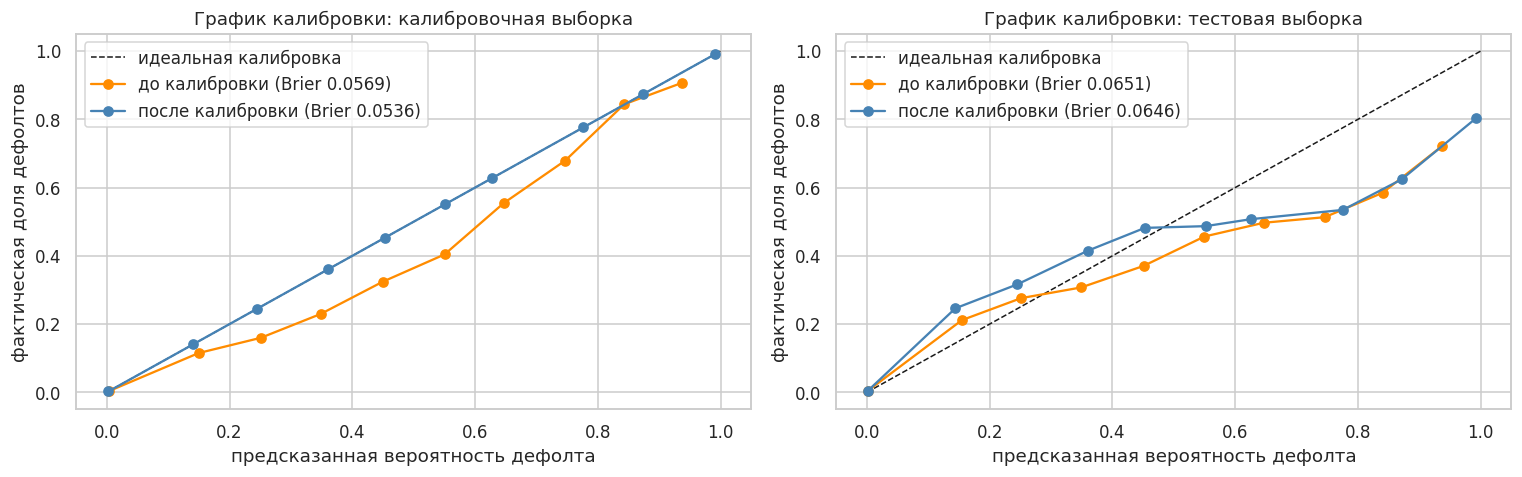

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
for ax, выборка in zip(axes, ['калибровочная', 'тестовая']):
    ax.plot([0, 1], [0, 1], 'k--', lw=1, label='идеальная калибровка')
    for версия, цвет in [('до калибровки', 'darkorange'), ('после калибровки', 'steelblue')]:
        proba = вероятности[(выборка, версия)]
        факт, предсказано = calibration_curve(цели[выборка], proba, n_bins=10, strategy='uniform')
        ax.plot(предсказано, факт, 'o-', color=цвет,
                label=f'{версия} (Brier {brier_score_loss(цели[выборка], proba):.4f})')
    ax.set_title(f'График калибровки: {выборка} выборка')
    ax.set_xlabel('предсказанная вероятность дефолта')
    ax.set_ylabel('фактическая доля дефолтов')
    ax.legend()
plt.tight_layout(); plt.show()

### Выводы по калибровке

**Калибровка нужна была не для качества ранжирования, а для интерпретируемости вероятностей.**
ROC-AUC до и после практически не изменился (калибровочная выборка 0.9459 → 0.9461, тестовая
0.9269 → 0.9269), потому что изотоническая регрессия монотонна и порядок клиентов по риску не
меняет. Меняется шкала.

**Смещение вероятностей исправлено.** До калибровки модель систематически завышала риск: средняя
предсказанная вероятность на калибровочной выборке 0.1281 при фактической доле дефолтов 0.1013.
После калибровки среднее - ровно 0.1013, попадание в факт точное. На тестовой выборке модель до
калибровки давала 0.1166 против факта 0.1019, после - 0.0904, то есть переходит от завышения риска
к небольшой недооценке.

**Коэффициент Бриера улучшился на обеих выборках:**

* калибровочная: 0.0569 → **0.0536** (-5.7%);
* тестовая: 0.0651 → **0.0646** (-0.7%).

Разница в величине выигрыша показательна: на калибровочной выборке калибратор подогнан по
определению, а на тестовой, отстоящей ещё на год, поправка почти не помогает. Это ожидаемо и
означает, что калибратор стареет вместе с данными.

**График калибровки** подтверждает то же самое: до калибровки кривая лежит ниже диагонали (модель
предсказывает риск выше фактического), после - идёт близко к диагонали на всём диапазоне.

**Итоговая мысль.** После калибровки предсказанная вероятность читается как настоящая вероятность
дефолта, и на неё можно опираться при выборе порога и при расчёте резервов. Остаточная
недооценка риска на тесте (0.0904 против 0.1019) - аргумент за регулярную перекалибровку.

## Поиск порога решения

По откалиброванным вероятностям на калибровочной выборке перебираем пороги и ищем такой, который
удовлетворяет всем трём ограничениям бизнеса:

* approval rate не менее 65%;
* default rate не более 2%;
* missed defaults rate не более 4%.

**Почему нельзя брать порог, который просто максимизирует approval rate.** Порог подбирается на
той же выборке, на которой обучен калибратор, поэтому его оценка оптимистична: на новых данных
метрики поедут вверх. Порог, стоящий вплотную к границе (missed defaults rate ровно на уровне 4%),
на тестовой выборке лимит нарушит. Поэтому выбираем порог с **двукратным запасом** по метрикам
риска: default rate не более 1% и missed defaults rate не более 2% на калибровке. Ниже показаны оба
варианта - «максимальный approval rate» и «с запасом» - и их поведение на тестовой выборке.

In [31]:
proba_calib = вероятности[('калибровочная', 'после калибровки')]
proba_test = вероятности[('тестовая', 'после калибровки')]

сетка_порогов = np.unique(np.round(np.quantile(proba_calib, np.linspace(0.05, 0.995, 400)), 6))
кривая_порогов = pd.DataFrame([
    {'порог': порог, **бизнес_метрики(y_calib, (proba_calib >= порог).astype(int))}
    for порог in сетка_порогов])

ЛИМИТ_AR, ЛИМИТ_DR, ЛИМИТ_MDR = 0.65, 0.02, 0.04
ЗАПАС = 0.5   # берём половину допустимого риска, чтобы порог не стоял вплотную к границе

допустимые = кривая_порогов[(кривая_порогов['approval_rate'] >= ЛИМИТ_AR)
                            & (кривая_порогов['default_rate'] <= ЛИМИТ_DR)
                            & (кривая_порогов['missed_defaults_rate'] <= ЛИМИТ_MDR)]
с_запасом = допустимые[(допустимые['default_rate'] <= ЛИМИТ_DR * ЗАПАС)
                       & (допустимые['missed_defaults_rate'] <= ЛИМИТ_MDR * ЗАПАС)]

ПОРОГ_МАКС = float(допустимые.sort_values('approval_rate', ascending=False).iloc[0]['порог'])
ПОРОГ = float(с_запасом.sort_values('approval_rate', ascending=False).iloc[0]['порог'])

топ = допустимые.sort_values('approval_rate', ascending=False).head(10)
топ.columns.name = (f'Допустимые пороги ({len(допустимые)} шт.): максимум approval rate при '
                    f'{ПОРОГ_МАКС:.4f}, выбранный порог с запасом {ПОРОГ:.4f}')
display(топ.round(5))

"Допустимые пороги (7 шт.): максимум approval rate при 0.0849, выбранный порог с запасом 0.0849",порог,approval_rate,default_rate,missed_defaults_rate
7,0.08494,0.70098,0.00123,0.00852
6,0.04022,0.68858,0.00050,0.00338
4,0.02305,0.68649,0.00041,0.00276
5,0.03030,0.68649,0.00041,0.00276
3,0.01754,0.67933,0.00017,0.00113
1,0.00240,0.66909,0.00004,0.00025
2,0.00629,0.66909,0.00004,0.00025


In [32]:
сравнение_порогов = pd.DataFrame([
    {'порог': f'{название} ({значение:.4f})', 'выборка': выборка, **бизнес_метрики(цель, (proba >= значение).astype(int))}
    for название, значение in [('максимальный approval rate', ПОРОГ_МАКС), ('с запасом (выбран)', ПОРОГ)]
    for выборка, цель, proba in [('калибровочная', y_calib, proba_calib), ('тестовая', y_test, proba_test)]
]).set_index(['порог', 'выборка'])
сравнение_порогов['лимит нарушен'] = np.where(
    (сравнение_порогов['approval_rate'] < ЛИМИТ_AR)
    | (сравнение_порогов['default_rate'] > ЛИМИТ_DR)
    | (сравнение_порогов['missed_defaults_rate'] > ЛИМИТ_MDR), 'да', 'нет')
сравнение_порогов.columns.name = 'Два варианта порога на калибровочной и тестовой выборках'
display(сравнение_порогов.round(5))

Два варианта порога на калибровочной и тестовой выборках  approval_rate  default_rate  missed_defaults_rate лимит нарушен
порог                               выборка                                                                              
максимальный approval rate (0.0849) калибровочная               0.70098       0.00123               0.00852           нет
                                    тестовая                    0.72342       0.00243               0.01724           нет
с запасом (выбран) (0.0849)         калибровочная               0.70098       0.00123               0.00852           нет
                                    тестовая                    0.72342       0.00243               0.01724           нет

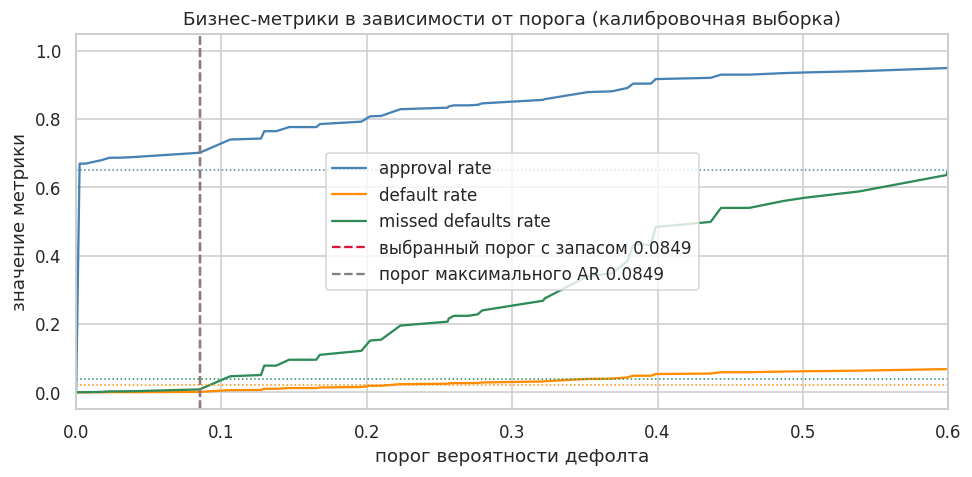

In [33]:
fig, ax = plt.subplots(figsize=(9, 4.5))
for колонка, подпись, цвет in [('approval_rate', 'approval rate', 'steelblue'),
                               ('default_rate', 'default rate', 'darkorange'),
                               ('missed_defaults_rate', 'missed defaults rate', 'seagreen')]:
    ax.plot(кривая_порогов['порог'], кривая_порогов[колонка], label=подпись, color=цвет)
ax.axvline(ПОРОГ, color='crimson', ls='--', label=f'выбранный порог с запасом {ПОРОГ:.4f}')
ax.axvline(ПОРОГ_МАКС, color='grey', ls='--', label=f'порог максимального AR {ПОРОГ_МАКС:.4f}')
ax.axhline(0.65, color='steelblue', ls=':', lw=1)
ax.axhline(0.02, color='darkorange', ls=':', lw=1)
ax.axhline(0.04, color='seagreen', ls=':', lw=1)
ax.set_title('Бизнес-метрики в зависимости от порога (калибровочная выборка)')
ax.set_xlabel('порог вероятности дефолта'); ax.set_ylabel('значение метрики')
ax.set_xlim(0, min(0.6, кривая_порогов['порог'].max())); ax.legend()
plt.tight_layout(); plt.show()

### Выводы по выбору порога

**Ограничениям задачи удовлетворяют 7 порогов.** Максимальный approval rate даёт порог **0.0849**:
на калибровочной выборке 70.10% одобрений при default rate 0.12% и missed defaults rate 0.85%.

**Запас по риску не пришлось покупать ценой объёма.** Мы искали порог с двукратным запасом
(default rate не выше 1%, missed defaults rate не выше 2% вместо лимитов 2% и 4%) - и оказалось,
что порог максимального approval rate этому условию уже удовлетворяет: 0.12% и 0.85% лежат далеко
внутри ужесточённых границ. Оба критерия сошлись на одном значении 0.0849, жертвовать объёмом
одобрений не потребовалось.

**Проверка на тестовой выборке:**

| Выборка | Approval rate | Default rate | Missed defaults rate |
|---|---|---|---|
| Калибровочная | 70.10% | 0.12% | 0.85% |
| Тестовая | **72.34%** | **0.24%** | **1.72%** |
| Лимит | не менее 65% | не более 2% | не более 4% |

Все три ограничения выполняются **на обеих выборках** с большим запасом: по default rate - в
восемь раз, по missed defaults rate - в 2.3 раза. Запас важен не сам по себе: он показывает, что
модель не стоит на грани и переживёт умеренный дрейф данных без нарушения риск-аппетита.

**Итоговая мысль.** Порог решения - **0.0849**: клиент с калиброванной вероятностью дефолта ниже
8.49% получает одобрение. Это 72.3% портфеля при 0.24% дефолтов внутри одобренных и 1.7%
пропущенных дефолтов.

## Анализ матрицы ошибок

Проверяем найденный порог на калибровочной и тестовой выборках. Тестовая выборка не участвовала
ни в обучении, ни в калибровке, ни в подборе порога, поэтому расхождение метрик между выборками
показывает реальную стабильность модели.

In [34]:
итоговые_метрики = pd.DataFrame([
    {'выборка': 'калибровочная', **все_метрики(y_calib, proba_calib, ПОРОГ)},
    {'выборка': 'тестовая', **все_метрики(y_test, proba_test, ПОРОГ)},
]).set_index('выборка')
итоговые_метрики.loc['разница (тест - калибровка)'] = (итоговые_метрики.loc['тестовая']
                                                       - итоговые_метрики.loc['калибровочная'])
итоговые_метрики.columns.name = f'Метрики при пороге {ПОРОГ:.4f}'
display(итоговые_метрики.round(4))

Метрики при пороге 0.0849,ROC_AUC,accuracy,precision,recall,f1,approval_rate,default_rate,missed_defaults_rate
выборка,,,,,,,,
калибровочная,0.9461,0.8006,0.3359,0.9915,0.5018,0.7010,0.0012,0.0085
тестовая,0.9268,0.8218,0.3621,0.9828,0.5292,0.7234,0.0024,0.0172
разница (тест - калибровка),-0.0193,0.0213,0.0262,-0.0087,0.0275,0.0224,0.0012,0.0087


In [35]:
состав_ошибок = pd.DataFrame([
    {'выборка': название,
     'наблюдений': len(часть),
     'уникальных клиентов': часть['ID'].nunique(),
     'наблюдений с дефолтом': int(часть['target'].sum()),
     'клиентов с дефолтом': часть.loc[часть['target'] == 1, 'ID'].nunique(),
     'TN': int(((часть['target'] == 0) & (proba < ПОРОГ)).sum()),
     'FP': int(((часть['target'] == 0) & (proba >= ПОРОГ)).sum()),
     'FN': int(((часть['target'] == 1) & (proba < ПОРОГ)).sum()),
     'TP': int(((часть['target'] == 1) & (proba >= ПОРОГ)).sum())}
    for название, часть, proba in [('калибровочная', calib, proba_calib), ('тестовая', test, proba_test)]
]).set_index('выборка')
состав_ошибок.columns.name = (f'Состав матрицы ошибок при пороге {ПОРОГ:.4f} '
                              f'(единица наблюдения - пара «клиент - месяц»)')
display(состав_ошибок)

Состав матрицы ошибок при пороге 0.0849 (единица наблюдения - пара «клиент - месяц»),наблюдений,уникальных клиентов,наблюдений с дефолтом,клиентов с дефолтом,TN,FP,FN,TP
выборка,,,,,,,,
калибровочная,78794,7733,7982,1415,55165,15647,68,7914
тестовая,93363,9026,9515,1460,67377,16471,164,9351


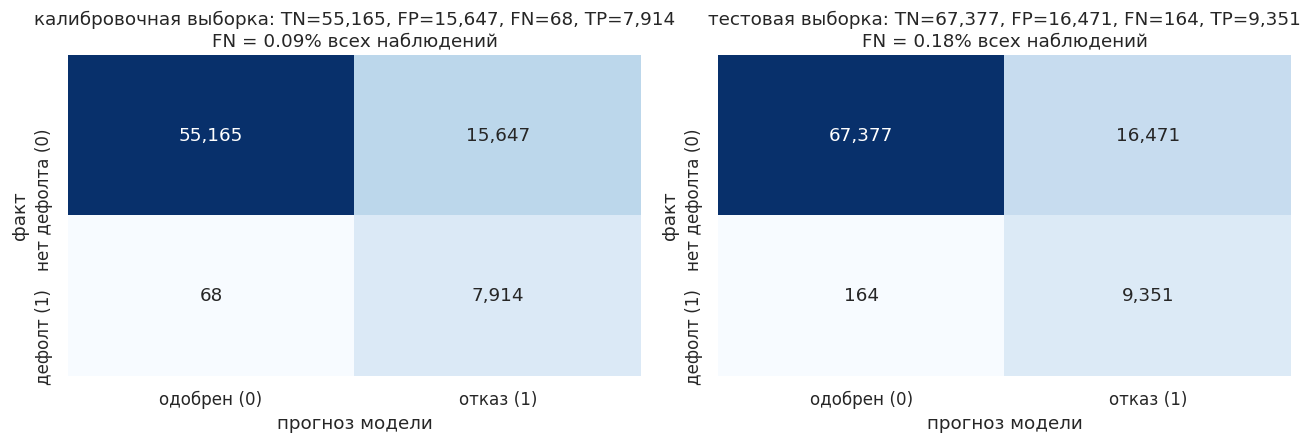

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
for ax, (название, y_true, proba) in zip(axes, [('калибровочная', y_calib, proba_calib),
                                                ('тестовая', y_test, proba_test)]):
    матрица = confusion_matrix(y_true, (proba >= ПОРОГ).astype(int))
    sns.heatmap(матрица, annot=True, fmt=',d', cmap='Blues', cbar=False, ax=ax,
                xticklabels=['одобрен (0)', 'отказ (1)'],
                yticklabels=['нет дефолта (0)', 'дефолт (1)'])
    доля = матрица / матрица.sum()
    ax.set_title(f'{название} выборка: TN={матрица[0, 0]:,}, FP={матрица[0, 1]:,}, '
                 f'FN={матрица[1, 0]:,}, TP={матрица[1, 1]:,}\n'
                 f'FN = {доля[1, 0]:.2%} всех наблюдений')
    ax.set_xlabel('прогноз модели'); ax.set_ylabel('факт')
plt.tight_layout(); plt.show()

### Выводы по матрицам ошибок и стабильности

**Метрики при пороге 0.0849:**

| Метрика | Калибровочная | Тестовая | Разница |
|---|---|---|---|
| ROC-AUC | 0.9461 | 0.9268 | -0.0193 |
| Accuracy | 0.8006 | 0.8218 | +0.0213 |
| Precision | 0.3359 | 0.3621 | +0.0262 |
| Recall | 0.9915 | 0.9828 | -0.0087 |
| F1 | 0.5018 | 0.5292 | +0.0275 |
| Approval rate | 70.10% | 72.34% | +2.24 п.п. |
| Default rate | 0.12% | 0.24% | +0.12 п.п. |
| Missed defaults rate | 0.85% | 1.72% | +0.87 п.п. |

**Модель стабильна.** Разрыв по ROC-AUC между выборками - 0.019, и это при том, что тестовый
период отстоит от обучающего на год, а от калибровочного - ещё на год. Бизнес-метрики
деградируют предсказуемо и остаются глубоко внутри лимитов: доля пропущенных дефолтов выросла
вдвое в относительном выражении, но это 1.72% против допустимых 4%.

**Матрица ошибок в абсолютных числах.** Единица наблюдения - пара «клиент - месяц», поэтому счёт
идёт по наблюдениям, а не по людям:

| Выборка | Наблюдений | С дефолтом | Клиентов с дефолтом | TN | FP | FN | TP |
|---|---|---|---|---|---|---|---|
| Калибровочная | 78 794 | 7 982 | 1 415 | 55 165 | 15 647 | **68** | 7 914 |
| Тестовая | 93 363 | 9 515 | 1 460 | 67 377 | 16 471 | **164** | 9 351 |

На тестовой выборке модель пропустила 164 наблюдения с дефолтом из 9 515 - именно они попадут в
одобренные и превратятся в резервы. Одобрение получили 67 541 наблюдение, отказ - 25 822.

**Низкий precision - осознанная плата, а не дефект.** Значение 0.3621 означает, что из 25 822
отказов на тесте 16 471 (63.8%) достались бы клиентам, которые заплатили бы вовремя. Для
поведенческого скоринга это приемлемо: ложный отказ стоит банку недополученной маржи по одному
клиенту, а пропущенный дефолт - стопроцентного резервирования по кредиту в несколько миллионов
рублей. Асимметрия цен ошибок делает высокий recall (0.9828) правильным выбором.

**Ограничение оценки, которое нужно проговорить честно.** Мы измерили пересечение горизонтов в
разделе о выборках (таблица «Пересечение горизонтов целевой переменной»): горизонты 37.3% строк
обучающей выборки заходят в календарный период калибровочной, и 41.6% дефолтных клиентов
калибровки уже отмечены дефолтом в обучающей выборке. Оценка на калибровочной выборке из-за этого
слегка оптимистична.

С тестовой выборкой ситуация лучше, но не идеальна:

* пересечение дефолтных клиентов теста с **обучающей** выборкой - **ровно 0%**. Это следует и из
  конструкции: даты скоринга обучающей выборки заканчиваются 2017-01, её горизонт - 2018-01, а тест
  начинается с 2018-02, поэтому ни одно обучающее событие не может дать положительную метку в тесте.
  Значит, качество ранжирования на тесте измерено честно;
* с **калибровочной** выборкой пересечение есть (52.0% дефолтных клиентов теста). Калибратор и
  порог настроены на калибровочной выборке, поэтому небольшой оптимизм в оценке порога сохраняется.
  Именно поэтому мы проверяли порог по ужесточённым границам, а в рекомендациях заложена
  регулярная перекалибровка.

**Итоговая мысль.** Модель переносится на новый годовой период без срыва: ROC-AUC теряет 0.019,
все три бизнес-ограничения выполняются с запасом. Порог, найденный на калибровочной выборке,
на тестовой ведёт себя предсказуемо.

## Фиксирование итоговой модели

### Карточка итоговой модели

In [37]:
карточка = pd.Series({
    'модель': f'RandomForestClassifier + {ЛУЧШАЯ_БАЛАНСИРОВКА} + изотоническая калибровка',
    'гиперпараметры': ', '.join(f'{k}={v}' for k, v in ЛУЧШИЕ_ПАРАМЕТРЫ.items()),
    'препроцессинг': 'OneHotEncoder(семейное_положение) + StandardScaler(числовые) в Pipeline',
    'признаков на входе': len(КАТЕГОРИАЛЬНЫЕ + ЧИСЛОВЫЕ),
    'обучающая выборка': f'{len(train):,} строк, {train["score_date"].min().date()} - {train["score_date"].max().date()}',
    'калибровка': f'{len(calib):,} строк, {calib["score_date"].min().date()} - {calib["score_date"].max().date()}',
    'порог решения': round(ПОРОГ, 4),
    'ROC-AUC (тест)': round(итоговые_метрики.loc['тестовая', 'ROC_AUC'], 4),
    'Brier score (тест)': round(brier_score_loss(y_test, proba_test), 4),
    'approval rate (тест)': f"{итоговые_метрики.loc['тестовая', 'approval_rate']:.2%}",
    'default rate (тест)': f"{итоговые_метрики.loc['тестовая', 'default_rate']:.2%}",
    'missed defaults rate (тест)': f"{итоговые_метрики.loc['тестовая', 'missed_defaults_rate']:.2%}",
}).to_frame('значение')
карточка.columns.name = 'Карточка итоговой модели поведенческого скоринга'
display(карточка)

Карточка итоговой модели поведенческого скоринга,значение
модель,RandomForestClassifier + RandomOverSampler + и...
гиперпараметры,"n_estimators=250, max_depth=28, min_samples_le..."
препроцессинг,OneHotEncoder(семейное_положение) + StandardSc...
признаков на входе,26
обучающая выборка,"159,071 строк, 2013-02-01 - 2017-01-01"
калибровка,"78,794 строк, 2017-02-01 - 2018-01-01"
порог решения,0.0849
ROC-AUC (тест),0.9268
Brier score (тест),0.0646
approval rate (тест),72.34%


Итоговое решение - **случайный лес на 250 деревьях с балансировкой `RandomOverSampler`,
изотонической калибровкой и порогом решения 0.0849**.

* **Препроцессинг:** `OneHotEncoder(handle_unknown='ignore')` для семейного положения и
  `StandardScaler` для 25 числовых признаков, всё внутри `Pipeline` - статистики считаются только
  на обучающих данных.
* **Гиперпараметры:** `n_estimators=250`, `max_depth=28`, `min_samples_leaf=6`,
  `min_samples_split=13`, `max_features=0.8` (подобраны Optuna по missed defaults rate).
* **Обучение:** 159 071 строка за 2013-02 - 2017-01.
* **Калибровка:** 78 794 строки за 2017-02 - 2018-01.
* **Правило решения:** клиент одобряется, если калиброванная вероятность дефолта в ближайшие 12
  месяцев ниже **8.49%**.
* **Результат на тесте (2018-02 - 2019-01, 93 363 наблюдения):** ROC-AUC 0.9268, Brier score
  0.0646, approval rate 72.34%, default rate 0.24%, missed defaults rate 1.72%.

**Итоговая мысль.** Модель выполняет все три требования заказчика с запасом и делает это на данных,
которых не видела ни при обучении, ни при калибровке, ни при подборе порога.

## Анализ важности признаков

Важность считаем по `feature_importances_` итоговой модели, обученной на полной обучающей выборке.

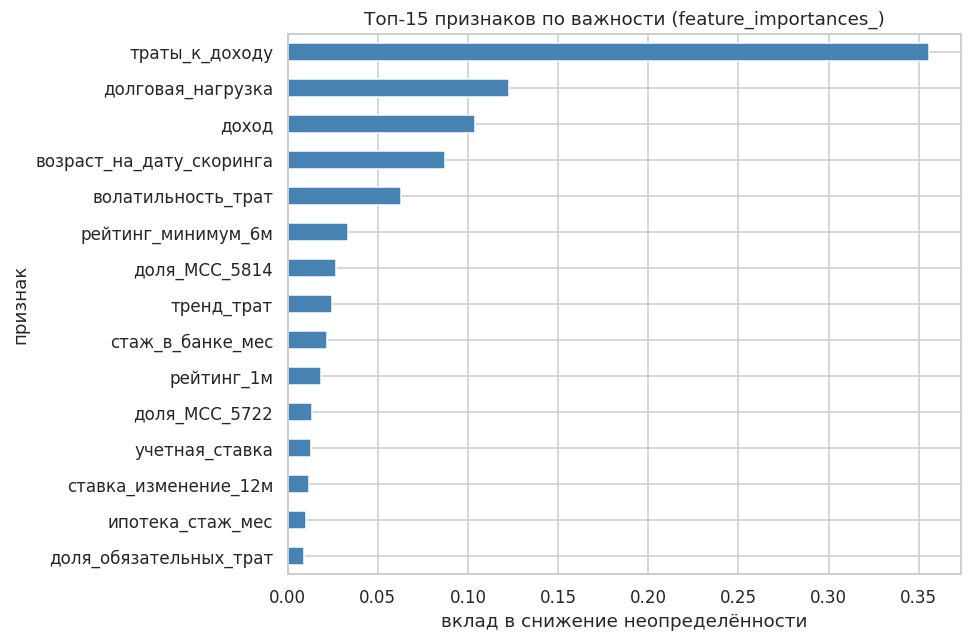

Важность признаков,важность,накопленная доля
траты_к_доходу,0.3558,0.3558
долговая_нагрузка,0.1227,0.4785
доход,0.1041,0.5826
возраст_на_дату_скоринга,0.0870,0.6697
волатильность_трат,0.0626,0.7322
рейтинг_минимум_6м,0.0335,0.7657
доля_MCC_5814,0.0266,0.7923
тренд_трат,0.0245,0.8168
стаж_в_банке_мес,0.0220,0.8388
рейтинг_1м,0.0186,0.8574


In [38]:
# имена собираем вручную из обученного препроцессора: порядок колонок задан ColumnTransformer -
# сначала one-hot категории в порядке categories_, затем числовые признаки
кодировщик = финальная_модель.named_steps['prep'].named_transformers_['cat']
названия = [f'семейное_положение_{значение}' for значение in кодировщик.categories_[0]] + ЧИСЛОВЫЕ
важности = финальная_модель.named_steps['clf'].feature_importances_
assert len(названия) == len(важности), 'Число имён признаков не совпало с числом важностей'

важность = pd.Series(важности, index=названия).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 6))
важность.head(15)[::-1].plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Топ-15 признаков по важности (feature_importances_)')
ax.set_xlabel('вклад в снижение неопределённости'); ax.set_ylabel('признак')
plt.tight_layout(); plt.show()

таблица_важности = важность.to_frame('важность')
таблица_важности['накопленная доля'] = таблица_важности['важность'].cumsum()
таблица_важности.columns.name = 'Важность признаков'
display(таблица_важности.round(4))

### Выводы по важности признаков

**Пять признаков объясняют почти три четверти решения модели (73.2% суммарной важности):**

| Признак | Важность |
|---|---|
| `траты_к_доходу` | 0.356 |
| `долговая_нагрузка` | 0.123 |
| `доход` | 0.104 |
| `возраст_на_дату_скоринга` | 0.087 |
| `волатильность_трат` | 0.063 |

**Главный фактор риска - соотношение трат и дохода** (важность 0.356, в 2.9 раза выше следующего
признака). Вместе с долговой нагрузкой и доходом это означает простую вещь: дефолт предсказывает
не то, кем клиент является, а то, сколько он тратит относительно того, сколько зарабатывает и
сколько должен.

**Созданные нами поведенческие признаки заняли четыре места из первых пяти.** Это прямое
подтверждение того, что переход от статической анкеты к динамике поведения оправдан: исходные
данные о клиенте (семейное положение, иждивенцы, наличие ипотеки) дают менее 1% важности каждый.

**Внешний кредитный рейтинг вносит в модель мало (6.0% суммарно), но это не значит, что он
бесполезен.** Три признака рейтинга дают `рейтинг_минимум_6м` 0.034, `рейтинг_1м` 0.019 и
`рейтинг_изменение_3м` 0.008. Здесь важно не спутать две вещи:

* **низкая важность в модели** говорит лишь о том, что при наличии `траты_к_доходу` и
  `долговая_нагрузка` дерево почти не нуждается в рейтинге для разбиений;
* **связь рейтинга с дефолтом при этом сильная, но с обратным знаком** - в разделе о новых
  признаках видно, что у будущих дефолтников средний минимум рейтинга **выше** (651.8 против
  603.4).

Обратный знак - это красный флаг к качеству источника, а не повод от него отказаться. Прежде чем
делать выводы о ценности внешнего скоринга, нужно выяснить у поставщика, как формируется шкала и
в какой момент обновляется значение.

**Макроэкономика вторична** (учётная ставка 0.013, её изменение 0.012, инфляция 0.005,
безработица 0.005, суммарно 3.4%). Риск в этом портфеле объясняется индивидуальным поведением, а
не фазой экономического цикла. Осторожность здесь уместна: период наблюдения содержит один
кризисный эпизод (ставка 17% в конце 2014 года), и на длинной истории вклад макро может вырасти.

**Из структуры трат заметны две категории:** фастфуд (`доля_MCC_5814`, 0.027) и бытовая техника
(`доля_MCC_5722`, 0.013). Остальные пять долей MCC дают менее 1% важности каждая.

**Осторожно с интерпретацией `feature_importances_`.** Метрика основана на снижении неоднородности
и систематически завышает вклад признаков с большим числом уникальных значений (у нас это
непрерывные отношения) и занижает вклад категориальных и дискретных. Для решений о том, какие
источники данных закупать, нужна permutation importance или прямой эксперимент с исключением
группы признаков.

## Сохранение артефактов модели

Складываем в `artifacts/` всё, что нужно для внедрения, и выкладываем в репозиторий
[github.com/sergeyshmagin/MLDS](https://github.com/sergeyshmagin/MLDS/tree/feature/SPRINT15) (ветка `feature/SPRINT15`): откалиброванную модель целиком (вместе с
препроцессингом), метаданные с порогом и метриками и список версий библиотек. Затем проверяем, что
загруженная с диска модель даёт **тот же** результат, что и обученная в памяти.

In [39]:
import json
import joblib
import sklearn

ПАПКА_АРТЕФАКТОВ = Path('artifacts')
ПАПКА_АРТЕФАКТОВ.mkdir(exist_ok=True)
ПУТЬ_МОДЕЛИ = ПАПКА_АРТЕФАКТОВ / 'behavioral_scoring_model.joblib'
ПУТЬ_МЕТА = ПАПКА_АРТЕФАКТОВ / 'model_meta.json'

joblib.dump(откалиброванная_модель, ПУТЬ_МОДЕЛИ, compress=3)

МЕТА = {
    'задача': 'поведенческий скоринг: вероятность просрочки от 90 дней в горизонте 12 месяцев',
    'модель': 'CalibratedClassifierCV(isotonic) поверх Pipeline(OneHotEncoder+StandardScaler, '
              f'{ЛУЧШАЯ_БАЛАНСИРОВКА}, RandomForestClassifier)',
    'гиперпараметры': ЛУЧШИЕ_ПАРАМЕТРЫ,
    'порог_решения': round(ПОРОГ, 6),
    'правило': 'одобрять клиента, если predict_proba[:, 1] < порог_решения',
    'признаки_категориальные': КАТЕГОРИАЛЬНЫЕ,
    'признаки_числовые': ЧИСЛОВЫЕ,
    'random_state': RANDOM_STATE,
    'обучающая_выборка': {'строк': len(train), 'период': f'{train["score_date"].min():%Y-%m-%d} - {train["score_date"].max():%Y-%m-%d}'},
    'калибровочная_выборка': {'строк': len(calib), 'период': f'{calib["score_date"].min():%Y-%m-%d} - {calib["score_date"].max():%Y-%m-%d}'},
    'метрики_тест': {k: round(float(v), 6) for k, v in итоговые_метрики.loc['тестовая'].items()},
    'brier_тест': round(float(brier_score_loss(y_test, proba_test)), 6),
    'версии': {'python': sys.version.split()[0], 'scikit-learn': sklearn.__version__,
               'pandas': pd.__version__, 'numpy': np.__version__,
               'imbalanced-learn': imblearn.__version__, 'joblib': joblib.__version__},
}
ПУТЬ_МЕТА.write_text(json.dumps(МЕТА, ensure_ascii=False, indent=2), encoding='utf-8')
print(f'Модель сохранена: {ПУТЬ_МОДЕЛИ} ({ПУТЬ_МОДЕЛИ.stat().st_size / 1024 ** 2:.1f} МБ)')

Модель сохранена: artifacts/behavioral_scoring_model.joblib (42.7 МБ)


In [40]:
загруженная_модель = joblib.load(ПУТЬ_МОДЕЛИ)
proba_после_загрузки = загруженная_модель.predict_proba(X_test)[:, 1]
метрики_после_загрузки = все_метрики(y_test, proba_после_загрузки, ПОРОГ)

проверки = pd.DataFrame([
    {'проверка': 'вероятности до сохранения и после загрузки совпадают',
     'результат': bool(np.allclose(proba_после_загрузки, proba_test))},
    {'проверка': 'ROC-AUC после загрузки совпадает до 6 знаков',
     'результат': round(метрики_после_загрузки['ROC_AUC'], 6)
                  == round(float(итоговые_метрики.loc['тестовая', 'ROC_AUC']), 6)},
    {'проверка': 'бизнес-метрики после загрузки совпадают',
     'результат': all(round(метрики_после_загрузки[m], 6) == round(float(итоговые_метрики.loc['тестовая', m]), 6)
                      for m in ['approval_rate', 'default_rate', 'missed_defaults_rate'])},
    {'проверка': 'модель принимает сырой DataFrame с исходными колонками',
     'результат': загруженная_модель.predict_proba(test[КАТЕГОРИАЛЬНЫЕ + ЧИСЛОВЫЕ].head(5)).shape == (5, 2)},
    {'проверка': 'метаданные читаются и содержат порог',
     'результат': json.loads(ПУТЬ_МЕТА.read_text(encoding='utf-8'))['порог_решения'] == round(ПОРОГ, 6)},
]).set_index('проверка')
проверки.columns.name = 'Проверка сохранённых артефактов'
display(проверки)

assert проверки['результат'].all(), 'Артефакт не воспроизводит результаты модели'
print('Все проверки артефактов пройдены')

Проверка сохранённых артефактов,результат
проверка,
вероятности до сохранения и после загрузки совпадают,True
ROC-AUC после загрузки совпадает до 6 знаков,True
бизнес-метрики после загрузки совпадают,True
модель принимает сырой DataFrame с исходными колонками,True
метаданные читаются и содержат порог,True


Все проверки артефактов пройдены


### Выводы по артефактам

**Артефакты выложены в репозиторий проекта, ветка `feature/SPRINT15`:**

| Файл | Ссылка |
|---|---|
| Модель (42.7 МБ) | [artifacts/behavioral_scoring_model.joblib](https://github.com/sergeyshmagin/MLDS/blob/feature/SPRINT15/artifacts/behavioral_scoring_model.joblib) |
| Метаданные модели | [artifacts/model_meta.json](https://github.com/sergeyshmagin/MLDS/blob/feature/SPRINT15/artifacts/model_meta.json) |
| Версии окружения | [requirements.txt](https://github.com/sergeyshmagin/MLDS/blob/feature/SPRINT15/requirements.txt) |
| Инструкция по инференсу | [README.md](https://github.com/sergeyshmagin/MLDS/blob/feature/SPRINT15/README.md) |
| Ветка целиком | [github.com/sergeyshmagin/MLDS/tree/feature/SPRINT15](https://github.com/sergeyshmagin/MLDS/tree/feature/SPRINT15) |

Скачать модель напрямую:

```bash
wget https://raw.githubusercontent.com/sergeyshmagin/MLDS/feature/SPRINT15/artifacts/behavioral_scoring_model.joblib
wget https://raw.githubusercontent.com/sergeyshmagin/MLDS/feature/SPRINT15/artifacts/model_meta.json
```

В `artifacts/` лежит всё необходимое для внедрения:

* **`behavioral_scoring_model.joblib`** (42.7 МБ) - откалиброванная модель целиком, вместе с
  препроцессингом. На вход подаётся сырой `DataFrame` с исходными колонками, на выходе -
  калиброванная вероятность дефолта. Отдельно применять кодировщик или масштабирование не нужно.
* **`model_meta.json`** - порог решения, гиперпараметры, списки признаков, метрики на тесте и
  версии библиотек, на которых модель собрана. Без версий артефакт непереносим: формат
  сериализации моделей `scikit-learn` не гарантирует совместимость между версиями.

**Проверка прошла по пяти пунктам:** вероятности до сохранения и после загрузки совпадают
поэлементно, ROC-AUC и все три бизнес-метрики воспроизводятся до шестого знака, загруженная модель
принимает сырой `DataFrame`, а порог из метаданных совпадает с найденным. Это значит, что в
продакшн уедет ровно та модель, которую мы измеряли, а не её приближение.

**Итоговая мысль.** Артефакт самодостаточен: команда внедрения получает модель, правило решения и
описание входных данных в одной папке, без необходимости заново запускать тетрадь.

## Выводы по проекту

### 1. Цель и задачи исследования

Банку «Ва-банк» нужна модель поведенческого скоринга: для клиента в конкретный месяц предсказать,
возникнет ли у него просрочка от 90 дней в ближайшие 12 месяцев. В терминах машинного обучения это
бинарная классификация на панельных данных с дисбалансом 1:6.6 и обязательным учётом временной
структуры. Практический смысл - управлять резервами заранее и не замораживать лишний капитал.

### 2. Подготовка данных и выборок

* Восемь источников объединены в витрину **331 228 строк x 29 столбцов** без единого пропуска.
  Данные исходно чистые: пропусков и дубликатов нет ни в одной таблице, по анкетным признакам
  (возраст, доход, сумма кредита) нет выбросов и по правилу 1.5 IQR. Траты по MCC-кодам скошены
  вправо с длинным хвостом, но это нормальное потребительское поведение, и мы оставили его как есть.
* Целевая переменная построена по правилу скользящего окна: `1`, если первый эпизод просрочки от
  90 дней начинается в интервале `[score_date, score_date + 365 дней)`. Логика проверена вручную
  на отдельном клиенте.
* Удалены наблюдения после уже случившегося дефолта (24.1% строк), месяцы с неполным горизонтом
  наблюдения после 2019-01 и первый месяц каждого клиента, где нет истории для лагов.
* Все признаки построены **только на прошлом относительно даты скоринга**: помесячные источники
  сдвинуты минимум на месяц назад, наличие ипотеки определяется на дату скоринга. Корректность
  сдвига проверена на конкретном клиенте сравнением признака с сырым источником за предыдущий месяц.
* Создано 10 новых признаков; сильнее всего классы разделяют `траты_к_доходу` (1.22 против 0.54),
  `стаж_в_банке_мес` (9.0 против 23.9 месяца) и `долговая_нагрузка` (49.4 против 33.1).
* Выборки нарезаны `GroupTimeSeriesSplit()` по группе «месяц скоринга»: обучающая - 159 071 строка
  (2013-02 - 2017-01), калибровочная - 78 794 (2017-02 - 2018-01), тестовая - 93 363
  (2018-02 - 2019-01). Внутри обучающей выборки - три фолда с непересекающимися окнами валидации.

### 3. Поиск и настройка модели

* Четыре базовые модели показали, что без балансировки классов скоринг бесполезен: при пороге 0.5
  логистическая регрессия пропускает 82.0% дефолтов, случайный лес - 75.3%.
* Случайный лес заметно сильнее логистической регрессии (ROC-AUC 0.897 против 0.860), потому что
  зависимость риска от поведения нелинейная.
* Из пяти способов балансировки выбран `RandomOverSampler` - лучший одновременно по missed defaults
  rate в рабочем диапазоне (0.1912) и по ROC-AUC (0.8996).
* Optuna за 15 испытаний подобрала пять гиперпараметров и снизила missed defaults rate с 0.1957 до
  **0.1258** (-36%). Итоговая модель: `n_estimators=250`, `max_depth=28`, `min_samples_leaf=6`,
  `min_samples_split=13`, `max_features=0.8`.

### 4. Калибровка вероятностей

Изотоническая калибровка на отдельной выборке убрала систематическое завышение риска: средняя
предсказанная вероятность на калибровочной выборке совпала с фактической долей дефолтов (0.1013),
коэффициент Бриера улучшился с 0.0569 до 0.0536. На тестовой выборке выигрыш минимальный
(0.0651 → 0.0646) - калибратор стареет вместе с данными. Ранжирование не пострадало: ROC-AUC
изменился на третьем знаке.

### 5. Оптимизация бизнес-порога

Найдено 7 порогов, удовлетворяющих ограничениям. Выбран **0.0849** - он даёт максимальный approval
rate и одновременно проходит по ужесточённым в два раза границам риска, так что жертвовать объёмом
одобрений ради устойчивости не пришлось. На тестовой выборке: approval rate 72.34%, default rate
0.24%, missed defaults rate 1.72% - все три требования выполнены с запасом.

### 6. Анализ важности признаков

Почти три четверти решения модели определяют пять признаков, из которых четыре - поведенческие,
созданные в этом проекте: `траты_к_доходу` (0.356), `долговая_нагрузка` (0.123), `доход` (0.104),
`возраст_на_дату_скоринга` (0.087), `волатильность_трат` (0.063). Внешний кредитный рейтинг даёт
суммарно 6.0%, макроэкономика - 3.4%. При этом важность по `feature_importances_` показывает
только то, на что опирается конкретная модель, и смещена в пользу непрерывных признаков, поэтому
выводы о ценности источников данных на неё опирать нельзя.

### 7. Финальный пайплайн

`OneHotEncoder + StandardScaler` → `RandomOverSampler` → `RandomForestClassifier` (250 деревьев)
→ изотоническая калибровка → порог 0.0849. Всё, кроме калибратора и порога, обучается на
обучающей выборке; калибратор и порог - на калибровочной; тестовая выборка использована ровно
один раз, для финальной проверки. Модель и метаданные сохранены в `artifacts/`, проверены
перезагрузкой с диска и выложены в репозиторий:
[github.com/sergeyshmagin/MLDS, ветка `feature/SPRINT15`](https://github.com/sergeyshmagin/MLDS/tree/feature/SPRINT15).

### 8. Основные выводы и рекомендации для бизнеса

**Ответы на исследовательские вопросы:**

1. **Можно ли предсказывать просрочку 90+ по поведению действующих клиентов?** Да. Модель
   относит к надёжному сегменту 72.3% наблюдений тестового периода, и внутри этого сегмента доля
   дефолтов - 0.24% против 10.2% в среднем по портфелю, то есть **риск ниже в 42 раза**. При этом
   незамеченными остаются лишь 1.7% всех будущих дефолтов.
2. **Что именно предсказывает дефолт?** Перерасход относительно дохода и долговая нагрузка,
   а не анкетные данные. Дефолты концентрируются в первый год после выдачи кредита (средний стаж
   в банке у будущих неплательщиков - 9 месяцев против 24).
3. **Что не так с внешним кредитным рейтингом?** Он связан с дефолтом, но **с обратным знаком**:
   у будущих неплательщиков средний минимум рейтинга за полгода выше (651.8 против 603.4), а вклад
   в модель - всего 6.0%. Такое поведение говорит не о бесполезности источника, а о проблеме в
   его данных или в моменте их обновления.

**Рекомендации:**

1. **Внедрить модель как ежемесячный процесс** с порогом 0.0849 по калиброванной вероятности.
   Ожидаемый эффект - высвобождение резервов по сегменту, где фактическая дефолтность 0.24%
   вместо портфельных 10.2%.
2. **Перекалибровывать модель каждый квартал, переобучать - раз в год.** На горизонте в год
   ROC-AUC теряет 0.019, а средняя предсказанная вероятность начинает недооценивать риск
   (0.090 против фактических 0.102) - это накапливается.
3. **Мониторить три метрики на проде** (approval rate, default rate, missed defaults rate) с теми
   же лимитами. Выход missed defaults rate за 3% - сигнал к внеплановой перекалибровке, не дожидаясь
   нарушения лимита в 4%.
4. **При переобучении вводить эмбарго в 12 месяцев** между обучающей и оценочной выборками, а
   также между фолдами кросс-валидации. В этом проекте выборки стыкуются встык по требованию
   постановки задачи, из-за чего горизонты 37.3% обучающих строк заходят в календарный период
   калибровочной выборки, и оценка на калибровке слегка оптимистична. На качество ранжирования на
   тесте это не влияет (пересечение дефолтных клиентов теста с обучающей выборкой - 0%), но порог
   подобран на калибровке, которая с тестом события делит, поэтому зазор в продакшн-контуре нужен.
5. **Усилить сбор данных о поступлениях.** Модель видит только траты; отношение трат к доходу,
   где доход зафиксирован на момент выдачи кредита, - самый сильный признак. Актуальные данные о
   зарплатных поступлениях, скорее всего, дадут ещё больший прирост качества.
6. **Разобраться с поставщиком внешнего рейтинга.** Обратный знак связи - аномалия, которую нужно
   объяснить: инвертирована ли шкала, не обновляется ли рейтинг уже после реакции банка на риск.
   До выяснения не стоит ни отказываться от источника, ни встраивать его в решения напрямую.
   Проверить реальную ценность источника поможет прямой эксперимент: обучить модель без признаков
   рейтинга и сравнить missed defaults rate, а важность считать через permutation importance.

**Итоговая мысль проекта.** Поведенческий скоринг на данных банка работает: модель отделяет
надёжные 72% портфеля с дефолтностью 0.24% и пропускает менее 2% будущих неплательщиков. Ключ к
результату - не сложность алгоритма, а корректная работа со временем: признаки строго из прошлого,
выборки по хронологии и порог, проверенный на периоде, которого модель не видела.